# Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import (classification_report, confusion_matrix,f1_score, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
import xgboost as xgb
import lightgbm as lgb
import requests, time, numpy as np, pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
import shap
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

import requests
from datetime import datetime, timedelta
import time

import warnings
warnings.filterwarnings('ignore')

# Load Data

In [2]:
ETA_PATH     = '/users/manvireddy/Downloads/ETA.csv'
AIRPORT_PATH = '/users/manvireddy/Downloads/Airport_info.csv'

eta     = pd.read_csv(ETA_PATH,     low_memory=False)
airport = pd.read_csv(AIRPORT_PATH, low_memory=False)

print(f'ETA shape       : {eta.shape}')
print(f'Airport shape   : {airport.shape}')
print(eta.columns.tolist())
print(airport.columns.tolist())
print('\n--- ETA Sample ---')
eta.head(2)

ETA shape       : (2739387, 64)
Airport shape   : (4565, 17)
['FLIGHT_HUB_EVENT_TYPE_CD', 'OPERAT_AIRLN_IATA_CD', 'OPERAT_FLIGHT_NBR', 'SCHD_LEG_DEP_AIRPRT_IATA_CD', 'SCHD_LEG_ARVL_AIRPRT_IATA_CD', 'ACTL_LEG_DEP_AIRPRT_IATA_CD', 'ACTL_LEG_ARVL_AIRPRT_IATA_CD', 'ETD_LCL_TMS', 'PREV_ETD_LCL_TMS', 'SCHD_FIRST_LEG_DEP_LCL_DT', 'SCHD_LEG_DEP_LCL_DT', 'SCHD_LEG_DEP_LCL_TM', 'SCHD_LEG_DEP_LCL_TMS', 'SCHD_LEG_ARVL_LCL_DT', 'SCHD_LEG_ARVL_LCL_TM', 'SCHD_LEG_ARVL_LCL_TMS', 'SCHD_LEG_DEP_GMT_TMS', 'SCHD_LEG_ARVL_GMT_TMS', 'ACTL_LEG_DEP_LCL_DT', 'ACTL_LEG_DEP_LCL_TM', 'ACTL_LEG_ARVL_LCL_DT', 'ACTL_LEG_ARVL_LCL_TM', 'ACTL_LEG_DEP_LCL_TMS', 'ACTL_LEG_ARVL_LCL_TMS', 'ACTL_LEG_DEP_GMT_TMS', 'ACTL_LEG_ARVL_GMT_TMS', 'LEG_DEP_VARNCE_MIN_QTY', 'LEG_ARVL_VARNCE_MIN_QTY', 'LEG_BLOCK_VARNCE_MIN_QTY', 'RS_IND', 'ACTL_LEG_DEP_GATE_CD', 'ACTL_LEG_ARVL_GATE_CD', 'ACTL_AIRCFT_TAIL_CD', 'SCHD_FLEET_CD', 'SCHD_SUBFLEET_CD', 'ACTL_FLEET_CD', 'ACTL_SUBFLEET_CD', 'DEP_AIRPRT_ENROUT_REGION_CD', 'ARVL_AIRPRT_ENROUT_REG

,FLIGHT_HUB_EVENT_TYPE_CD,OPERAT_AIRLN_IATA_CD,OPERAT_FLIGHT_NBR,SCHD_LEG_DEP_AIRPRT_IATA_CD,SCHD_LEG_ARVL_AIRPRT_IATA_CD,ACTL_LEG_DEP_AIRPRT_IATA_CD,ACTL_LEG_ARVL_AIRPRT_IATA_CD,ETD_LCL_TMS,PREV_ETD_LCL_TMS,SCHD_FIRST_LEG_DEP_LCL_DT,...,SUBSEQUENT_LEG_OF_DIVERT_IND,LNIATA_TXT,PRSNEL_ID,FOS_AGENT_SINE_HOME_CITY_CD,FOS_AGENT_SINE_CD,USER_AUDIT_TMS,ACTN_CD,FLIGHT_TYPE_CD,MULTI_OPS_IND,SF_LOAD_TMS
0,CYCLE,OO,4965.0,DFW,GCK,DFW,GCK,2023-03-19 12:54:00.0,NaN,2023-03-19,...,N,NaN,NaN,NaN,NaN,NaN,NaN,C,N,2025-07-24 19:50:13.902
1,CYCLE,OO,6486.0,DFW,AEX,DFW,AEX,2025-03-15 16:45:00.0,NaN,2025-03-15,...,N,NaN,NaN,NaN,NaN,NaN,NaN,C,N,2025-07-24 19:50:13.902


# Merge Airport_info to ETA Dataset

In [3]:
df_ETA     = eta.copy()
df_Airport = airport.copy()

# 1. Departure airport metadata
df_dep_merged = pd.merge(
    df_ETA, df_Airport,
    left_on='SCHD_LEG_DEP_AIRPRT_IATA_CD', right_on='AIRPRT_CD', how='left'
)
depature_cols = {col: f"DEP_{col}" for col in df_Airport.columns}
df_dep_merged.rename(columns=depature_cols, inplace=True)

# 2. Arrival airport metadata
df_final = pd.merge(
    df_dep_merged, df_Airport,
    left_on='SCHD_LEG_ARVL_AIRPRT_IATA_CD', right_on='AIRPRT_CD', how='left'
)
arrival_cols = {col: f"ARR_{col}" for col in df_Airport.columns}
df_final.rename(columns=arrival_cols, inplace=True)

# 3. Drop redundant join keys
drop_cols = [c for c in [
    'DEP_AIRPRT_CD','ARR_AIRPRT_CD','SF_LOAD_TMS_x','SF_LOAD_TMS_y',
    'DEP_CNTRY_CD','ARR_CNTRY_CD','DEP_AIRPRT_NM','ARR_AIRPRT_NM',
    'ARR_CITY_METRO_IATA_CD','DEP_CITY_METRO_IATA_CD','ARR_SF_LOAD_TMS'
] if c in df_final.columns]
df_final.drop(columns=drop_cols, inplace=True)

print(f'Final shape: {df_final.shape}')
df_final.head(2)
df = df_final.copy()

Final shape: (2739387, 87)


# Cleaning/Transformation of Airport Columns – Lat, Lon & Elevation Distance

In [4]:
# --- STEP 1: DMS to Decimal Coordinate Transformation ---
def dcmls_to_dd(deg, minute, second, hemi):
    """Converts Degrees Minutes Seconds to Decimal Degrees"""
    if pd.isna(deg) or pd.isna(minute) or pd.isna(second):
        return np.nan
    dd = float(deg) + float(minute)/60 + float(second)/3600
    if hemi in ['S', 'W']:
        dd *= -1
    return dd

# Departure coordinates
df['DEP_LAT_DECI'] = df.apply(lambda x: dcmls_to_dd(x['DEP_LAT_DEGREE_QTY'], x['DEP_LAT_MINUTE_QTY'], x['DEP_LAT_SECOND_QTY'], x['DEP_LAT_HEMSPHR_CD']), axis=1)
df['DEP_LNG_DECI'] = df.apply(lambda x: dcmls_to_dd(x['DEP_LNGTD_DEGREE_QTY'], x['DEP_LNGTD_MINUTE_QTY'], x['DEP_LNGTD_SECOND_QTY'], x['DEP_LNGTD_HEMSPHR_CD']), axis=1)

# Arrival coordinates
df['ARR_LAT_DECI'] = df.apply(lambda x: dcmls_to_dd(x['ARR_LAT_DEGREE_QTY'], x['ARR_LAT_MINUTE_QTY'], x['ARR_LAT_SECOND_QTY'], x['ARR_LAT_HEMSPHR_CD']), axis=1)
df['ARR_LNG_DECI'] = df.apply(lambda x: dcmls_to_dd(x['ARR_LNGTD_DEGREE_QTY'], x['ARR_LNGTD_MINUTE_QTY'], x['ARR_LNGTD_SECOND_QTY'], x['ARR_LNGTD_HEMSPHR_CD']), axis=1)

# --- STEP 2: Great Circle Distance (Haversine) ---
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculates distance between two points in KM"""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

df['FLIGHT_DISTANCE_KME'] = haversine_distance(df['DEP_LAT_DECI'], df['DEP_LNG_DECI'], df['ARR_LAT_DECI'], df['ARR_LNG_DECI'])

# --- STEP 4: Drop raw DMS columns ---
cols_to_drop = [
    'DEP_WRLD_AREA_DOT_CD','DEP_LAT_DEGREE_QTY','DEP_LAT_MINUTE_QTY','DEP_LAT_SECOND_QTY','DEP_LAT_HEMSPHR_CD',
    'DEP_LNGTD_DEGREE_QTY','DEP_LNGTD_MINUTE_QTY','DEP_LNGTD_SECOND_QTY','DEP_LNGTD_HEMSPHR_CD',
    'ARR_STATE_PROVNC_CD','DEP_STATE_PROVNC_CD','ARR_LNGST_RUNWAY_FT_QTY','ARR_ELEVATN_FT_QTY',
    'ARR_LAT_DEGREE_QTY','ARR_LAT_MINUTE_QTY','ARR_LAT_SECOND_QTY','ARR_LAT_HEMSPHR_CD',
    'ARR_LNGTD_DEGREE_QTY','ARR_LNGTD_MINUTE_QTY','ARR_LNGTD_SECOND_QTY','ARR_LNGTD_HEMSPHR_CD','ARR_WRLD_AREA_DOT_CD'
]
df_merged_final = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f'Final shape: {df_merged_final.shape}')
df_merged_final.head(2)

Final shape: (2739387, 70)


,FLIGHT_HUB_EVENT_TYPE_CD,OPERAT_AIRLN_IATA_CD,OPERAT_FLIGHT_NBR,SCHD_LEG_DEP_AIRPRT_IATA_CD,SCHD_LEG_ARVL_AIRPRT_IATA_CD,ACTL_LEG_DEP_AIRPRT_IATA_CD,ACTL_LEG_ARVL_AIRPRT_IATA_CD,ETD_LCL_TMS,PREV_ETD_LCL_TMS,SCHD_FIRST_LEG_DEP_LCL_DT,...,ACTN_CD,FLIGHT_TYPE_CD,MULTI_OPS_IND,DEP_LNGST_RUNWAY_FT_QTY,DEP_ELEVATN_FT_QTY,DEP_LAT_DECI,DEP_LNG_DECI,ARR_LAT_DECI,ARR_LNG_DECI,FLIGHT_DISTANCE_KME
0,CYCLE,OO,4965.0,DFW,GCK,DFW,GCK,2023-03-19 12:54:00.0,NaN,2023-03-19,...,NaN,C,N,13400.0,606.0,32.897222,-97.0375,37.927500,-100.724167,651.377679
1,CYCLE,OO,6486.0,DFW,AEX,DFW,AEX,2025-03-15 16:45:00.0,NaN,2025-03-15,...,NaN,C,N,13400.0,606.0,32.897222,-97.0375,31.327222,-92.548333,457.372134


# Define Target Variables

In [5]:
# Binary classification target: delayed >= 10 min?
df_merged_final['is_delayed'] = (df_merged_final['LEG_ARVL_VARNCE_MIN_QTY'] >= 10).astype(int)

# Regression target: actual delay minutes (NaN for on-time flights)
df_merged_final['delay_minutes'] = np.where(
    df_merged_final['LEG_ARVL_VARNCE_MIN_QTY'] >= 10,
    df_merged_final['LEG_ARVL_VARNCE_MIN_QTY'],
    np.nan
)

print('--- Binary Classification Target (is_delayed) ---')
print(df_merged_final['is_delayed'].value_counts(normalize=True))
print(f'Delay rate: {df_merged_final["is_delayed"].mean():.1%}')
print('\n--- Regression Target (delay_minutes) ---')
print(df_merged_final['delay_minutes'].describe())
print(f'Final shape: {df_merged_final.shape}')

--- Binary Classification Target (is_delayed) ---
is_delayed
1    0.574556
0    0.425444
Name: proportion, dtype: float64
Delay rate: 57.5%

--- Regression Target (delay_minutes) ---
count    1.573930e+06
mean     1.108414e+02
std      1.586679e+02
min      1.000000e+01
25%      3.000000e+01
50%      6.300000e+01
75%      1.270000e+02
max      2.356000e+03
Name: delay_minutes, dtype: float64
Final shape: (2739387, 72)


# Cleaning & Transforming Date & Time Columns

In [6]:
# 1. Combine Date + Time into a single datetime column
def combine_Date_time(date_col, time_col, df):
    combined = df[date_col].astype(str) + " " + df[time_col].astype(str)
    return pd.to_datetime(combined, errors='coerce')

df_merged_final['schd_dep_dt'] = combine_Date_time('SCHD_LEG_DEP_LCL_DT', 'SCHD_LEG_DEP_LCL_TM', df_merged_final)
df_merged_final['schd_arr_dt'] = combine_Date_time('SCHD_LEG_ARVL_LCL_DT', 'SCHD_LEG_ARVL_LCL_TM', df_merged_final)

# 2. Extract date components (kept for EDA grouping)
df_merged_final['dep_hour']          = df_merged_final['schd_dep_dt'].dt.hour
df_merged_final['dep_dayofweek']     = df_merged_final['schd_dep_dt'].dt.dayofweek
df_merged_final['dep_month']         = df_merged_final['schd_dep_dt'].dt.month
df_merged_final['is_weekend']        = (df_merged_final['dep_dayofweek'] >= 5).astype(int)
df_merged_final['is_holiday_season'] = df_merged_final['dep_month'].isin([11, 12, 1]).astype(int)
df_merged_final['is_peak_hour']      = ((df_merged_final['dep_hour'].between(6, 9)) | 
                                        (df_merged_final['dep_hour'].between(15, 19))).astype(int)

# 3. Route feature
df_merged_final['SCHD_LEG_ARVL_AIRPRT_IATA_CD'] = df_merged_final['SCHD_LEG_ARVL_AIRPRT_IATA_CD'].fillna('UNKNOWN')
df_merged_final['route'] = df_merged_final['SCHD_LEG_DEP_AIRPRT_IATA_CD'] + '_' + df_merged_final['SCHD_LEG_ARVL_AIRPRT_IATA_CD']

# 4. Cyclical time encoding (captures circular nature of time: 23:59 is close to 00:00)
def cyclical_time_encoding(df, col_name):
    mask    = df[col_name].notna()
    minutes = df.loc[mask, col_name].dt.hour * 60 + df.loc[mask, col_name].dt.minute
    df.loc[mask, f"{col_name}_SIN"] = np.sin(2 * np.pi * minutes / 1440)
    df.loc[mask, f"{col_name}_COS"] = np.cos(2 * np.pi * minutes / 1440)
    df[f"{col_name}_SIN"] = df[f"{col_name}_SIN"].fillna(0)
    df[f"{col_name}_COS"] = df[f"{col_name}_COS"].fillna(0)
    return df

for col in ['schd_dep_dt', 'schd_arr_dt']:
    df_merged_final = cyclical_time_encoding(df_merged_final, col)

# 5. Scheduled flight duration (recovery buffer)
df_merged_final['schd_expected_flight_duration'] = (
    df_merged_final['schd_arr_dt'] - df_merged_final['schd_dep_dt']).dt.total_seconds() / 60

cols_to_drop = [
    'SCHD_FIRST_LEG_DEP_LCL_DT','SCHD_LEG_DEP_LCL_TM','SCHD_LEG_ARVL_LCL_DT','SCHD_LEG_ARVL_LCL_TM',  
    'ACTL_LEG_DEP_LCL_DT','ACTL_LEG_DEP_LCL_TM','ACTL_LEG_ARVL_LCL_DT','ACTL_LEG_ARVL_LCL_TM',
    'SCHD_LEG_DEP_LCL_TMS','SCHD_LEG_ARVL_LCL_TMS','SCHD_LEG_DEP_GMT_TMS','SCHD_LEG_ARVL_GMT_TMS',
    'ACTL_LEG_DEP_LCL_TMS','ACTL_LEG_ARVL_LCL_TMS','SCHD_LEG_DEP_GMT_TS','SCHD_LEG_ARVL_GMT_TS',
    'ESTM_LEG_DEP_LCL_TS','PREV_ESTM_LEG_DEP_LCL_TS','schd_arr_dt','LNIATA_MSG_TXT','PRSNL_ID','FOS_AGT_HOME_CITY_CD','USR_AUDT_TS' ]
    
df_cleaning_final = df_merged_final.drop(columns=[c for c in cols_to_drop if c in df_merged_final.columns])
print(f'Final shape: {df_cleaning_final.shape}')
df_cleaning_final.head(2)

Final shape: (2739387, 71)


,FLIGHT_HUB_EVENT_TYPE_CD,OPERAT_AIRLN_IATA_CD,OPERAT_FLIGHT_NBR,SCHD_LEG_DEP_AIRPRT_IATA_CD,SCHD_LEG_ARVL_AIRPRT_IATA_CD,ACTL_LEG_DEP_AIRPRT_IATA_CD,ACTL_LEG_ARVL_AIRPRT_IATA_CD,ETD_LCL_TMS,PREV_ETD_LCL_TMS,SCHD_LEG_DEP_LCL_DT,...,dep_month,is_weekend,is_holiday_season,is_peak_hour,route,schd_dep_dt_SIN,schd_dep_dt_COS,schd_arr_dt_SIN,schd_arr_dt_COS,schd_expected_flight_duration
0,CYCLE,OO,4965.0,DFW,GCK,DFW,GCK,2023-03-19 12:54:00.0,NaN,2023-03-19 00:00:00.000,...,3.0,1,0,0,DFW_GCK,-0.233445,-0.972370,-0.608761,-0.793353,96.0
1,CYCLE,OO,6486.0,DFW,AEX,DFW,AEX,2025-03-15 16:45:00.0,NaN,2025-03-15 00:00:00.000,...,3.0,1,0,1,DFW_AEX,-0.946930,-0.321439,-0.999914,-0.013090,72.0


# Data Cleaning

In [7]:
# 1. Keep only POST_FINAL_IND == 'Y' (final posted truth for each flight)
df_cleaning_final = df_cleaning_final[df_cleaning_final['POST_FINAL_IND'] == 'Y'].copy()

# 2. TTL_POST_QTY: cap at 50 to remove extreme outliers
df_cleaning_final['TTL_POST_QTY'] = df_cleaning_final['TTL_POST_QTY'].astype(int)
df_cleaning_final['TTL_POST_QTY'] = df_cleaning_final['TTL_POST_QTY'].clip(upper=50)

# 3. Departure variance: fill NaN with 0 (no report = assumed on-time), then cap at 99th pct
df_cleaning_final['LEG_DEP_VARNCE_MIN_QTY'] = df_cleaning_final['LEG_DEP_VARNCE_MIN_QTY'].fillna(0)
outlier_cap_value = df_cleaning_final['LEG_DEP_VARNCE_MIN_QTY'].quantile(0.99)
df_cleaning_final['LEG_DEP_VARNCE_MIN_QTY'] = df_cleaning_final['LEG_DEP_VARNCE_MIN_QTY'].clip(upper=outlier_cap_value)

# 4. Parse ETD timestamps
df_cleaning_final['ETD_LCL_TMS']      = pd.to_datetime(df_cleaning_final['ETD_LCL_TMS'],      errors='coerce')
df_cleaning_final['PREV_ETD_LCL_TMS'] = pd.to_datetime(df_cleaning_final['PREV_ETD_LCL_TMS'], errors='coerce')

# 5. ETD Push-back: how late vs schedule the current ETD estimate is
df_cleaning_final['etd_push_back_min'] = (
    df_cleaning_final['ETD_LCL_TMS'] - df_cleaning_final['schd_dep_dt']).dt.total_seconds() / 60
df_cleaning_final['etd_push_back_min'] = df_cleaning_final['etd_push_back_min'].fillna(0)

# 6. ETD Volatility: how much the estimate changed from the previous one
df_cleaning_final['etd_volatility_min'] = (
    df_cleaning_final['ETD_LCL_TMS'] - df_cleaning_final['PREV_ETD_LCL_TMS']).dt.total_seconds() / 60
df_cleaning_final['etd_volatility_min'] = df_cleaning_final['etd_volatility_min'].fillna(0)

# 7. Minutes to scheduled departure: clip to [-120, 360]
df_cleaning_final['MINS_TO_SCHD_DEP_QTY'] = df_cleaning_final['MINS_TO_SCHD_DEP_QTY'].astype(int)
df_cleaning_final['MINS_TO_SCHD_DEP_QTY'] = df_cleaning_final['MINS_TO_SCHD_DEP_QTY'].clip(lower=-120, upper=360)

# 8. Fleet swap flag: actual fleet != scheduled fleet?
df_cleaning_final['is_fleet_swap'] = (
    df_cleaning_final['SCHD_FLEET_CD'].fillna(-1) != df_cleaning_final['ACTL_FLEET_CD'].fillna(-1)).astype(int)

# 9. Route frequency
route_counts = df_cleaning_final['route'].value_counts().to_dict()
df_cleaning_final['route_freq'] = df_cleaning_final['route'].map(route_counts)

# 10. Remove cancelled and diverted flights (target undefined for these)
df_cleaning_final = df_cleaning_final[(df_cleaning_final['CANCEL_IND'] == 0) & (df_cleaning_final['DIVERT_IND'] == 0)]

cols_to_drop = [
    'ETD_LCL_TMS','PREV_ETD_LCL_TMS','schd_dep_dt','LEG_ARVL_VARNCE_MIN_QTY',  # already encoded into targets
    'POST_FINAL_IND','POST_NBR','ACTL_FLEET_CD','ACTL_SUBFLEET_CD','SCHD_SUBFLEET_CD','SCHD_FLEET_CD',
    'SCHD_LEG_DEP_AIRPRT_IATA_CD','SCHD_LEG_ARVL_AIRPRT_IATA_CD','CANCEL_IND','DIVERT_IND']

df_cleaned = df_cleaning_final.drop(columns=[c for c in cols_to_drop if c in df_cleaning_final.columns])
print(f'Final shape: {df_cleaned.shape}')
df_cleaned.head(2)

Final shape: (1266641, 61)


,FLIGHT_HUB_EVENT_TYPE_CD,OPERAT_AIRLN_IATA_CD,OPERAT_FLIGHT_NBR,ACTL_LEG_DEP_AIRPRT_IATA_CD,ACTL_LEG_ARVL_AIRPRT_IATA_CD,SCHD_LEG_DEP_LCL_DT,ACTL_LEG_DEP_GMT_TMS,ACTL_LEG_ARVL_GMT_TMS,LEG_DEP_VARNCE_MIN_QTY,LEG_BLOCK_VARNCE_MIN_QTY,...,route,schd_dep_dt_SIN,schd_dep_dt_COS,schd_arr_dt_SIN,schd_arr_dt_COS,schd_expected_flight_duration,etd_push_back_min,etd_volatility_min,is_fleet_swap,route_freq
0,CYCLE,OO,4965.0,DFW,GCK,2023-03-19 00:00:00.000,2023-03-19 17:56:00.000,2023-03-19 19:20:00.000,2.0,-12.0,...,DFW_GCK,-0.233445,-0.972370,-0.608761,-7.933533e-01,96.0,0.0,0.0,0,3304
2,CYCLE,OO,4931.0,DFW,LBB,2024-10-09 00:00:00.000,2024-10-09 21:40:00.000,2024-10-09 22:49:00.000,-1.0,-10.0,...,DFW_LBB,-0.941176,-0.337917,-1.000000,-1.836970e-16,79.0,0.0,0.0,0,11069


# Handling Outliers for columns

OUTLIER SUMMARY — Before Treatment

delay_minutes:
  Mean=63.5  Median=36.0  Std=93.5  Min=10.0  Max=2114.0
  IQR bounds: [-62.0, 154.0]
  Outliers: 28,136 (7.51%)  |  1st-99th pct: [10.0, 484.0]

etd_push_back_min:
  Mean=19.4  Median=0.0  Std=58.7  Min=-2982.0  Max=2123.0
  IQR bounds: [-22.5, 37.5]
  Outliers: 186,377 (14.71%)  |  1st-99th pct: [0.0, 225.0]

etd_volatility_min:
  Mean=4.5  Median=0.0  Std=11.2  Min=-240.0  Max=596.0
  IQR bounds: [-12.0, 20.0]
  Outliers: 61,859 (4.88%)  |  1st-99th pct: [-5.0, 40.0]

schd_expected_flight_duration:
  Mean=147.1  Median=106.0  Std=157.6  Min=-45.0  Max=2080.0
  IQR bounds: [-102.5, 373.5]
  Outliers: 25,321 (2.00%)  |  1st-99th pct: [34.0, 960.0]


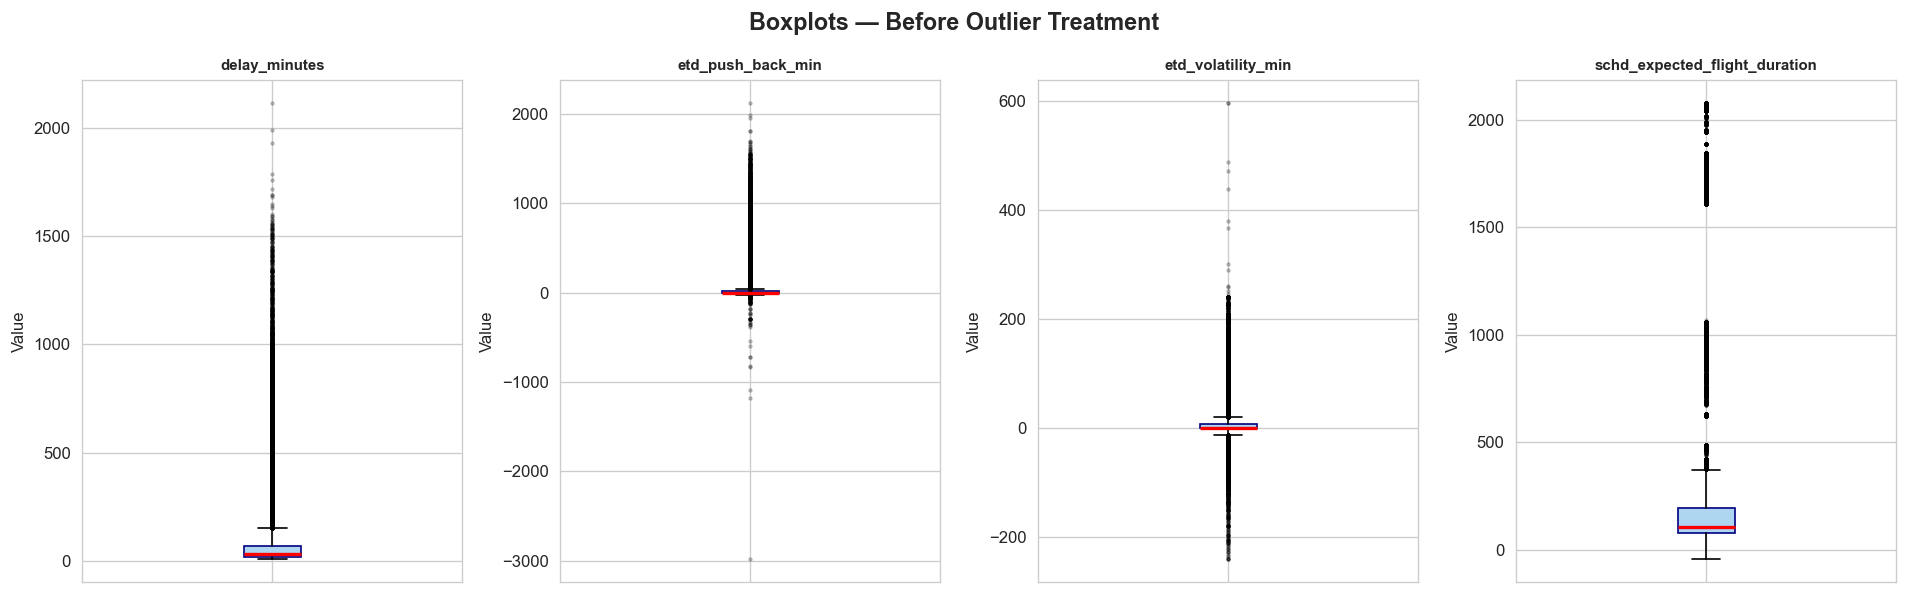

 delay_minutes winsorized to [10.0, 484.0]
 etd_push_back_min winsorized to [0.0, 225.0]
 etd_volatility_min winsorized to [-5.0, 40.0]
 schd_expected_flight_duration winsorized to [34.0, 960.0]


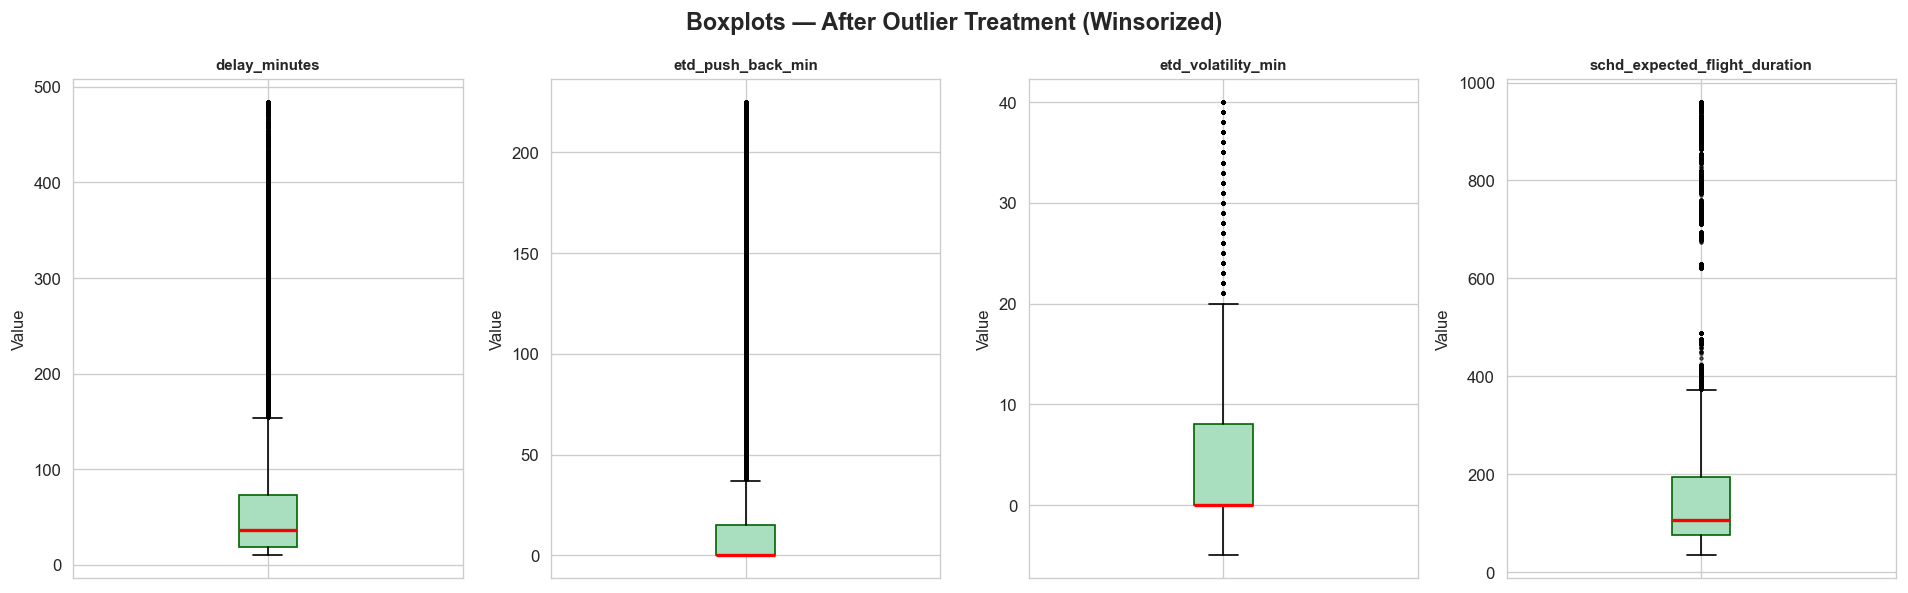


OUTLIER SUMMARY — After Treatment
delay_minutes: mean=60.7  median=36.0  min=10.0  max=484.0
etd_push_back_min: mean=17.3  median=0.0  min=0.0  max=225.0
etd_volatility_min: mean=4.4  median=0.0  min=-5.0  max=40.0
schd_expected_flight_duration: mean=143.3  median=106.0  min=34.0  max=960.0


In [8]:
outlier_cols = ['delay_minutes', 'etd_push_back_min', 'etd_volatility_min', 'schd_expected_flight_duration']
outlier_cols = [c for c in outlier_cols if c in df_cleaned.columns]

print("=" * 60)
print("OUTLIER SUMMARY — Before Treatment")
print("=" * 60)
for col in outlier_cols:
    s = df_cleaned[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    print(f"\n{col}:")
    print(f"  Mean={s.mean():.1f}  Median={s.median():.1f}  Std={s.std():.1f}  Min={s.min():.1f}  Max={s.max():.1f}")
    print(f"  IQR bounds: [{q1 - 1.5*iqr:.1f}, {q3 + 1.5*iqr:.1f}]")
    print(f"  Outliers: {n_out:,} ({n_out/len(s):.2%})  |  1st-99th pct: [{s.quantile(0.01):.1f}, {s.quantile(0.99):.1f}]")

n = len(outlier_cols)
fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
fig.suptitle("Boxplots — Before Outlier Treatment", fontsize=14, fontweight='bold')
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df_cleaned[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', color='gray', alpha=0.3, markersize=3))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
plt.tight_layout()
plt.show()

for col in outlier_cols:
    p01, p99 = df_cleaned[col].quantile(0.01), df_cleaned[col].quantile(0.99)
    df_cleaned[col] = df_cleaned[col].clip(p01 if col != 'delay_minutes' else None, p99)
    print(f" {col} winsorized to [{p01:.1f}, {p99:.1f}]")

fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
fig.suptitle("Boxplots — After Outlier Treatment (Winsorized)", fontsize=14, fontweight='bold')
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df_cleaned[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#A9DFBF', color='darkgreen'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', color='gray', alpha=0.3, markersize=3))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("OUTLIER SUMMARY — After Treatment")
print("=" * 60)
for col in outlier_cols:
    s = df_cleaned[col].dropna()
    print(f"{col}: mean={s.mean():.1f}  median={s.median():.1f}  min={s.min():.1f}  max={s.max():.1f}")

# Weather Data Enrichment (Open-Meteo Free API)

We fetch historical daily weather for each departure airport on its scheduled departure date.
Open-Meteo is free, requires no API key, and returns realistic historical meteorological data.
Docs: https://open-meteo.com/en/docs/historical-weather-api

In [9]:
def fetch_weather(lat, lon, date_str):
    _nan = dict(precip_mm=np.nan, wind_kmh=np.nan, temp_max_c=np.nan, temp_min_c=np.nan, snow_cm=np.nan, wx_code=np.nan)
    try:
        r = requests.get("https://archive-api.open-meteo.com/v1/archive", params=dict(
            latitude=round(lat, 4), longitude=round(lon, 4), start_date=date_str, end_date=date_str,
            daily="precipitation_sum,wind_speed_10m_max,temperature_2m_max,temperature_2m_min,snowfall_sum,weathercode",
            timezone="auto", wind_speed_unit="kmh"), timeout=12)
        r.raise_for_status()
        d = r.json().get("daily", {})
        g = lambda k: (d.get(k) or [np.nan])[0]
        return dict(precip_mm=g("precipitation_sum"), wind_kmh=g("wind_speed_10m_max"), temp_max_c=g("temperature_2m_max"),
                    temp_min_c=g("temperature_2m_min"), snow_cm=g("snowfall_sum"), wx_code=g("weathercode"))
    except Exception:
        return _nan

def fetch_weather_batch(unique_keys_df, lat_col, lon_col, date_col, max_workers=20, label=""):
    rows = unique_keys_df[[lat_col, lon_col, date_col]].dropna().drop_duplicates()
    total = len(rows)
    print(f"[{label}] {total:,} unique (lat, lon, date) combos to fetch …")
    cache = {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(fetch_weather, row[1], row[2], row[3]): 
                   (row[1], row[2], row[3]) for row in rows.itertuples(index=True)}
        for i, fut in enumerate(as_completed(futures), 1):
            cache[futures[fut]] = fut.result()
            if i % 500 == 0 or i == total:
                print(f"  [{label}] {i:,}/{total:,} done")
    print(f"[{label}] complete — {len(cache):,} records.\n")
    return cache

df_cleaned["_dep_date_str"] = pd.to_datetime(df_cleaned["SCHD_LEG_DEP_LCL_DT"], errors="coerce").dt.strftime("%Y-%m-%d")
df_cleaned["_arr_date_str"] = df_cleaned["_dep_date_str"]
df_cleaned["_dep_lat_r"] = df_cleaned["DEP_LAT_DECI"].round(2)
df_cleaned["_dep_lon_r"] = df_cleaned["DEP_LNG_DECI"].round(2)
df_cleaned["_arr_lat_r"] = df_cleaned["ARR_LAT_DECI"].round(2)
df_cleaned["_arr_lon_r"] = df_cleaned["ARR_LNG_DECI"].round(2)

dep_keys = df_cleaned[["_dep_lat_r", "_dep_lon_r", "_dep_date_str"]].rename(columns={"_dep_lat_r": "lat", "_dep_lon_r": "lon", "_dep_date_str": "date"})
arr_keys = df_cleaned[["_arr_lat_r", "_arr_lon_r", "_arr_date_str"]].rename(columns={"_arr_lat_r": "lat", "_arr_lon_r": "lon", "_arr_date_str": "date"})
all_unique = pd.concat([dep_keys, arr_keys]).drop_duplicates().dropna()
print(f"Total unique (airport, date) combos after dedup: {len(all_unique):,}")

shared_cache = fetch_weather_batch(all_unique, "lat", "lon", "date", max_workers=20, label="ALL")

def attach_wx(df, lat_col, lon_col, date_col, cache, prefix):
    keys = list(zip(df[lat_col], df[lon_col], df[date_col]))
    wx_df = pd.DataFrame([cache.get(k, {}) for k in keys], index=df.index)
    wx_df.columns = [f"{prefix}{c}" for c in wx_df.columns]
    return pd.concat([df, wx_df], axis=1)

df_cleaned = attach_wx(df_cleaned, "_dep_lat_r", "_dep_lon_r", "_dep_date_str", shared_cache, prefix="dep_wx_")
df_cleaned = attach_wx(df_cleaned, "_arr_lat_r", "_arr_lon_r", "_arr_date_str", shared_cache, prefix="arr_wx_")

def _adverse(prefix, df):
    return ((df[f"{prefix}precip_mm"] > 5) | (df[f"{prefix}wind_kmh"] > 50) 
            | (df[f"{prefix}snow_cm"] > 1) | (df[f"{prefix}wx_code"] >= 60)).astype(np.int8)

df_cleaned["dep_wx_is_adverse"] = _adverse("dep_wx_", df_cleaned)
df_cleaned["arr_wx_is_adverse"] = _adverse("arr_wx_", df_cleaned)
df_cleaned["wx_either_adverse"] = (df_cleaned["dep_wx_is_adverse"] | df_cleaned["arr_wx_is_adverse"]).astype(np.int8)

for side in ("dep", "arr"):
    p = f"{side}_wx_"
    df_cleaned[f"{p}precip_x_wind"] = df_cleaned[f"{p}precip_mm"] * df_cleaned[f"{p}wind_kmh"]
    df_cleaned[f"{p}temp_range_c"]  = df_cleaned[f"{p}temp_max_c"] - df_cleaned[f"{p}temp_min_c"]

wx_cols = [c for c in df_cleaned.columns if c.startswith(("dep_wx_", "arr_wx_")) or c == "wx_either_adverse"]
float_wx = [c for c in wx_cols if df_cleaned[c].dtype == float]
df_cleaned[float_wx] = df_cleaned[float_wx].fillna(df_cleaned[float_wx].median())
df_cleaned.drop(columns=["_dep_date_str", "_arr_date_str", "_dep_lat_r", "_dep_lon_r",
                         "_arr_lat_r", "_arr_lon_r"], inplace=True, errors="ignore")

print("=== WEATHER FEATURE SUMMARY ===")
print(df_cleaned[wx_cols].describe().round(3))
print(f"\nTotal weather columns : {len(wx_cols)}\ndf_cleaned shape      : {df_cleaned.shape}")
print("\n--- STD CHECK (should NOT be ~0) ---")
print(df_cleaned[wx_cols].std().round(4))

Total unique (airport, date) combos after dedup: 361,044
[ALL] 361,044 unique (lat, lon, date) combos to fetch …
  [ALL] 500/361,044 done
  [ALL] 1,000/361,044 done
  [ALL] 1,500/361,044 done
  [ALL] 2,000/361,044 done
  [ALL] 2,500/361,044 done
  [ALL] 3,000/361,044 done
  [ALL] 3,500/361,044 done
  [ALL] 4,000/361,044 done
  [ALL] 4,500/361,044 done
  [ALL] 5,000/361,044 done
  [ALL] 5,500/361,044 done
  [ALL] 6,000/361,044 done
  [ALL] 6,500/361,044 done
  [ALL] 7,000/361,044 done
  [ALL] 7,500/361,044 done
  [ALL] 8,000/361,044 done
  [ALL] 8,500/361,044 done
  [ALL] 9,000/361,044 done
  [ALL] 9,500/361,044 done
  [ALL] 10,000/361,044 done
  [ALL] 10,500/361,044 done
  [ALL] 11,000/361,044 done
  [ALL] 11,500/361,044 done
  [ALL] 12,000/361,044 done
  [ALL] 12,500/361,044 done
  [ALL] 13,000/361,044 done
  [ALL] 13,500/361,044 done
  [ALL] 14,000/361,044 done
  [ALL] 14,500/361,044 done
  [ALL] 15,000/361,044 done
  [ALL] 15,500/361,044 done
  [ALL] 16,000/361,044 done
  [ALL] 16,5

# Handling Categorical Columns & Transformation

In [10]:
# Remove duplicate column names
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.duplicated()]

# 1. Log-transform regression target (handles right skew; log1p safe for 0-min delays)
df_cleaned['log_delay_minutes'] = np.log1p(df_cleaned['delay_minutes'])

# 2. Binary mapping for Yes/No indicator columns
binary_map = {'Y': 1, 'N': 0, 'y': 1, 'n': 0}
for col in ['RS_IND', 'MULTI_OPS_IND']:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].map(binary_map).fillna(0).astype(int)

df_cleaned['airline_hist_delay_rate'] = (df_cleaned.groupby('OPERAT_AIRLN_IATA_CD')['is_delayed']
    .transform(lambda x: x.shift(1).expanding().mean()))
global_mean = df_cleaned['is_delayed'].mean()
df_cleaned['airline_hist_delay_rate'] = df_cleaned['airline_hist_delay_rate'].fillna(global_mean)
df_cleaned = df_cleaned.reset_index(drop=True)

# 4. Flight type grouping (A = dominant baseline, C = second, rest = OTHER)
print(df_cleaned['FLIGHT_TYPE_CD'].value_counts())

top_types = ['A', 'C']
if 'FLIGHT_TYPE_GROUPED_C' not in df_cleaned.columns:
    df_cleaned['FLIGHT_TYPE_GROUPED'] = df_cleaned['FLIGHT_TYPE_CD'].apply(lambda x: x if x in top_types else "OTHER")
    df_cleaned = pd.get_dummies(df_cleaned, columns=['FLIGHT_TYPE_GROUPED'], drop_first=True)
    df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.duplicated()]
flight_A_rows = df_cleaned[(~df_cleaned['FLIGHT_TYPE_GROUPED_C']) & (~df_cleaned['FLIGHT_TYPE_GROUPED_OTHER'])]
print(f'Number of type-A (baseline) flights: {len(flight_A_rows)}')

# 5. Hub event type grouping
print(df_cleaned['FLIGHT_HUB_EVENT_TYPE_CD'].value_counts())
normal_events = ['CYCLE', 'ETD']
if 'EVENT_TYPE_GROUPED_ETD' not in df_cleaned.columns:
    df_cleaned['EVENT_TYPE_GROUPED'] = df_cleaned['FLIGHT_HUB_EVENT_TYPE_CD'].apply(lambda x: x if x in normal_events else "OTHER")
    df_cleaned = pd.get_dummies(df_cleaned, columns=['EVENT_TYPE_GROUPED'], drop_first=True)
    df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.duplicated()]

# 6. Route delay probability & severity
prob_map     = df_cleaned.groupby('route')['is_delayed'].mean().to_dict()
severity_map = df_cleaned[df_cleaned['is_delayed'] == 1].groupby('route')['delay_minutes'].mean().to_dict()
df_cleaned['route_delay_prob']   = df_cleaned['route'].map(prob_map)
df_cleaned['route_avg_severity'] = df_cleaned['route'].map(severity_map).fillna(0)

# 7. Arrival enroute region: clean and one-hot encode
if 'ARVL_AIRPRT_ENROUT_REGION_CD' in df_cleaned.columns:
    df_cleaned['ARVL_AIRPRT_ENROUT_REGION_CD'] = (df_cleaned['ARVL_AIRPRT_ENROUT_REGION_CD'].fillna(-1).astype(int).astype(str))
    region_dummies = pd.get_dummies(df_cleaned['ARVL_AIRPRT_ENROUT_REGION_CD'], prefix='ARR_ENROUTE_REGION')
    df_cleaned = pd.concat([df_cleaned, region_dummies], axis=1)
    df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.duplicated()]
    df_cleaned.drop(columns=['ARVL_AIRPRT_ENROUT_REGION_CD'], inplace=True)

df_transformed = df_cleaned.copy()
print(f'Final shape: {df_transformed.shape}')
df_transformed.head(2)

FLIGHT_TYPE_CD
A    780516
C    479385
G      3038
F      2190
X      1107
Y       276
R       125
Q         4
Name: count, dtype: int64
Number of type-A (baseline) flights: 780516
FLIGHT_HUB_EVENT_TYPE_CD
CYCLE        813974
ETD          449443
CREATE         2008
DCSN           1126
REINSTATE        45
DIVERSION        39
RETURN            6
Name: count, dtype: int64
Final shape: (1266641, 93)


,FLIGHT_HUB_EVENT_TYPE_CD,OPERAT_AIRLN_IATA_CD,OPERAT_FLIGHT_NBR,ACTL_LEG_DEP_AIRPRT_IATA_CD,ACTL_LEG_ARVL_AIRPRT_IATA_CD,SCHD_LEG_DEP_LCL_DT,ACTL_LEG_DEP_GMT_TMS,ACTL_LEG_ARVL_GMT_TMS,LEG_DEP_VARNCE_MIN_QTY,LEG_BLOCK_VARNCE_MIN_QTY,...,EVENT_TYPE_GROUPED_ETD,EVENT_TYPE_GROUPED_OTHER,route_delay_prob,route_avg_severity,ARR_ENROUTE_REGION_-1,ARR_ENROUTE_REGION_11,ARR_ENROUTE_REGION_12,ARR_ENROUTE_REGION_13,ARR_ENROUTE_REGION_14,ARR_ENROUTE_REGION_15
0,CYCLE,OO,4965.0,DFW,GCK,2023-03-19 00:00:00.000,2023-03-19 17:56:00.000,2023-03-19 19:20:00.000,2.0,-12.0,...,False,False,0.213974,59.000000,False,True,False,False,False,False
1,CYCLE,OO,4931.0,DFW,LBB,2024-10-09 00:00:00.000,2024-10-09 21:40:00.000,2024-10-09 22:49:00.000,-1.0,-10.0,...,False,False,0.264949,67.481572,False,True,False,False,False,False


# Weather – Correlation Heatmaps

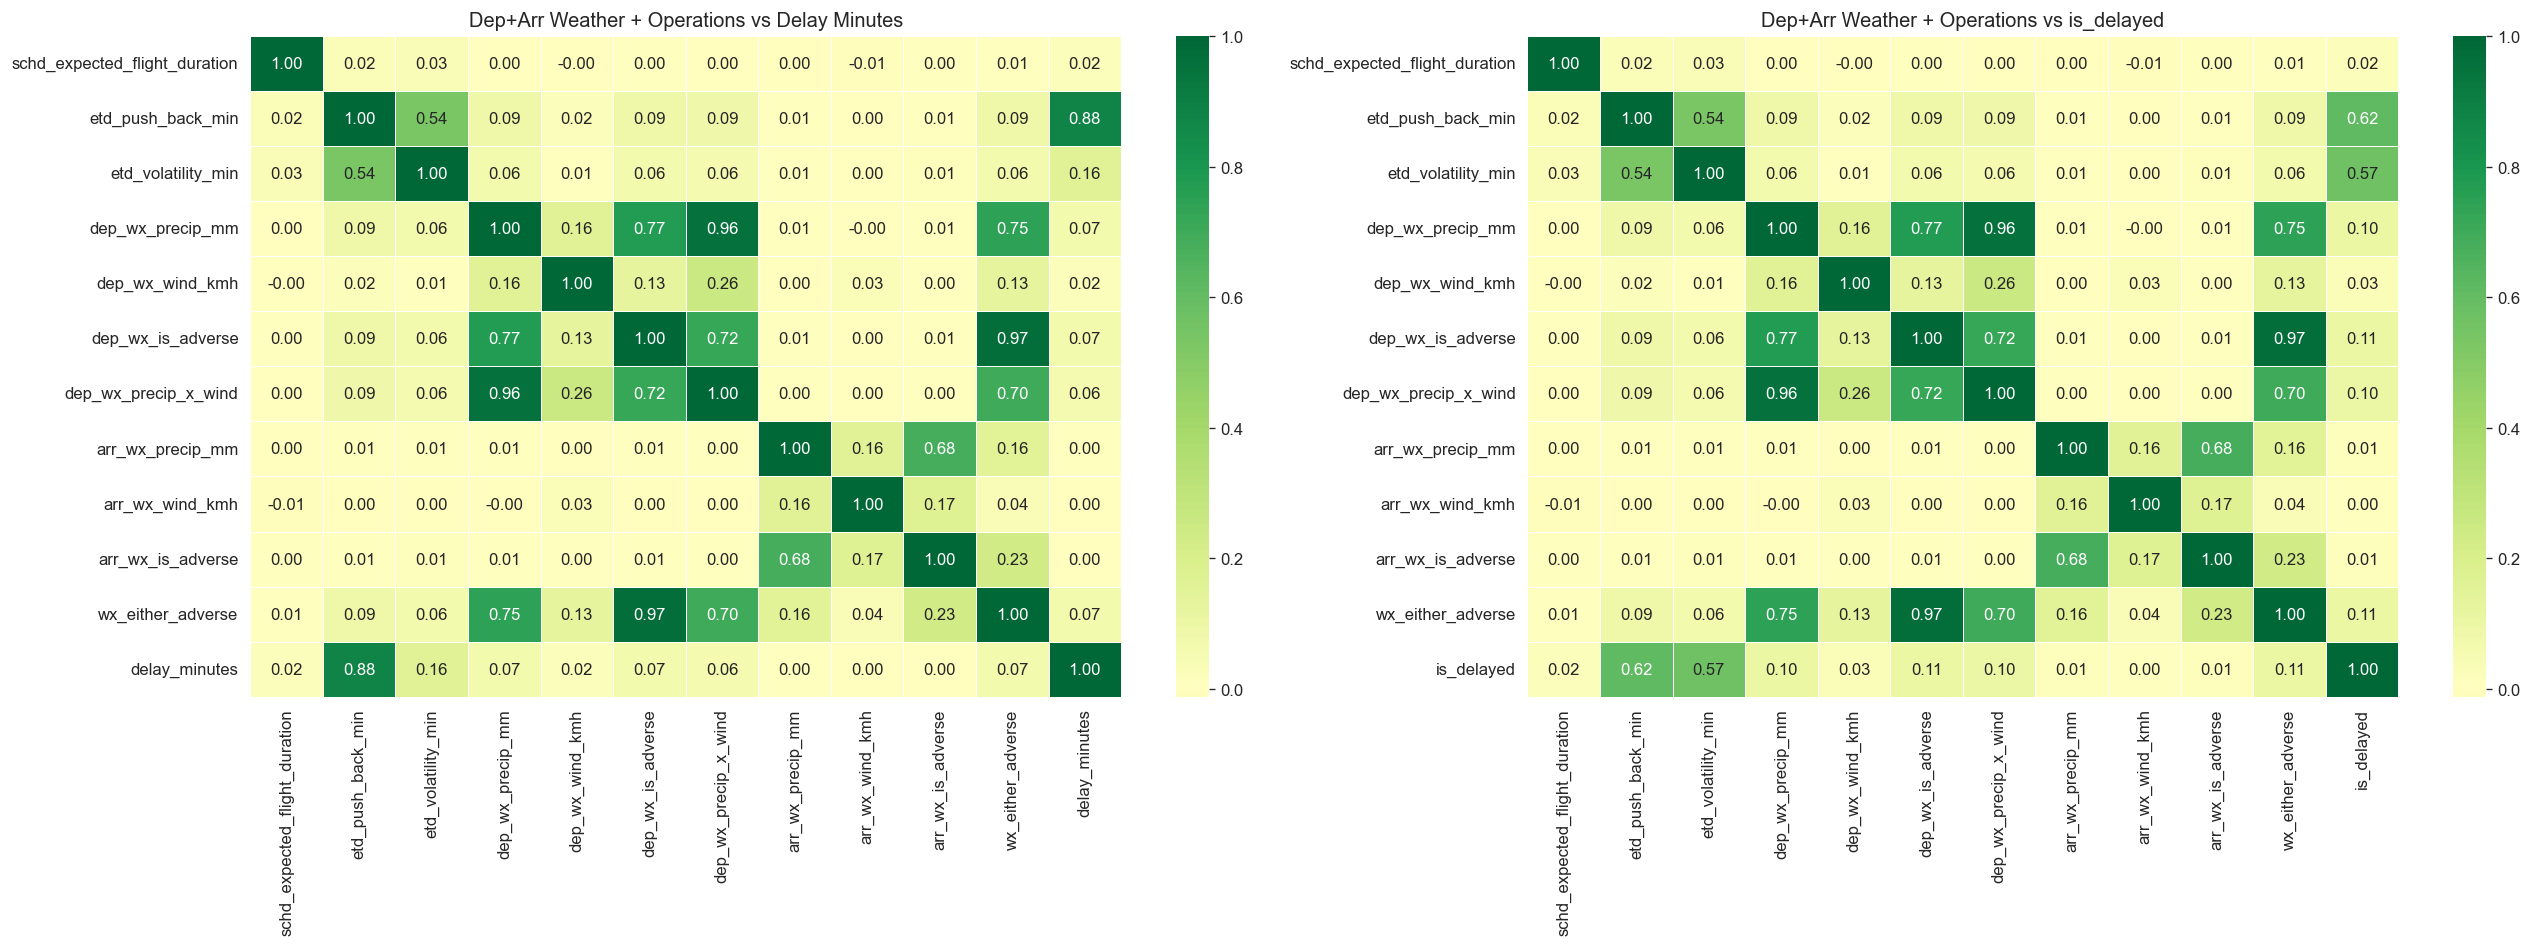


--- WEATHER CORRELATIONS WITH is_delayed (ranked) ---
wx_either_adverse       0.1087
dep_wx_is_adverse       0.1085
dep_wx_precip_mm        0.1040
dep_wx_precip_x_wind    0.0993
dep_wx_wind_kmh         0.0311
arr_wx_is_adverse       0.0148
arr_wx_precip_mm        0.0132
arr_wx_wind_kmh         0.0049


In [11]:
dep_wx_cols = ['dep_wx_precip_mm', 'dep_wx_wind_kmh', 'dep_wx_is_adverse',
               'dep_wx_precip_x_wind']
arr_wx_cols = ['arr_wx_precip_mm', 'arr_wx_wind_kmh', 'arr_wx_is_adverse']
op_cols     = ['schd_expected_flight_duration', 'etd_push_back_min',
               'etd_volatility_min']

corr_reg = df_cleaned[
    op_cols + dep_wx_cols + arr_wx_cols + ['wx_either_adverse', 'delay_minutes']
].corr()

corr_class = df_cleaned[
    op_cols + dep_wx_cols + arr_wx_cols + ['wx_either_adverse', 'is_delayed']
].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
sns.heatmap(corr_reg,   annot=True, cmap="RdYlGn", center=0,
            ax=axes[0], fmt=".2f", linewidths=0.4)
axes[0].set_title("Dep+Arr Weather + Operations vs Delay Minutes")

sns.heatmap(corr_class, annot=True, cmap="RdYlGn", center=0,
            ax=axes[1], fmt=".2f", linewidths=0.4)
axes[1].set_title("Dep+Arr Weather + Operations vs is_delayed")

plt.tight_layout()
plt.show()

# Print ranked weather correlations with is_delayed
wx_all = dep_wx_cols + arr_wx_cols + ['wx_either_adverse']
print("\n--- WEATHER CORRELATIONS WITH is_delayed (ranked) ---")
print(
    df_cleaned[wx_all + ['is_delayed']]
    .corr()['is_delayed']
    .drop('is_delayed')
    .abs()
    .sort_values(ascending=False)
    .round(4)
    .to_string()
)

# Feature Selection

Removing 14 columns: ['FOS_AGENT_SINE_CD', 'USER_AUDIT_TMS', 'DEP_LNG_DECI', 'ACTL_LEG_DEP_AIRPRT_IATA_CD', 'DEP_LNGST_RUNWAY_FT_QTY', 'FLIFO_DELAY_REASON_CD', 'PRSNEL_ID', 'EXP_GMT_TMS', 'LNIATA_TXT', 'DEP_LAT_DECI', 'ACTN_CD', 'FOS_AGENT_SINE_HOME_CITY_CD', 'DEP_AIRPRT_ENROUT_REGION_CD', 'DEP_ELEVATN_FT_QTY']

--- FINAL MODEL FEATURES ---
['MINS_TO_SCHD_DEP_QTY', 'TTL_POST_QTY', 'MULTI_OPS_IND', 'schd_expected_flight_duration', 'is_fleet_swap', 'etd_volatility_min', 'airline_hist_delay_rate', 'route_delay_prob', 'route_avg_severity', 'schd_dep_dt_SIN', 'schd_dep_dt_COS', 'schd_arr_dt_SIN', 'schd_arr_dt_COS', 'is_holiday_season', 'dep_wx_precip_mm', 'dep_wx_is_adverse', 'dep_wx_precip_x_wind', 'arr_wx_is_adverse', 'wx_either_adverse', 'ARR_ENROUTE_REGION_11', 'ARR_ENROUTE_REGION_12', 'ARR_ENROUTE_REGION_13', 'ARR_ENROUTE_REGION_14', 'ARR_ENROUTE_REGION_15', 'is_delayed', 'delay_minutes', 'log_delay_minutes']
Final Feature Count: (1266641, 27)
Auto-identified 2 redundant columns: ['dep

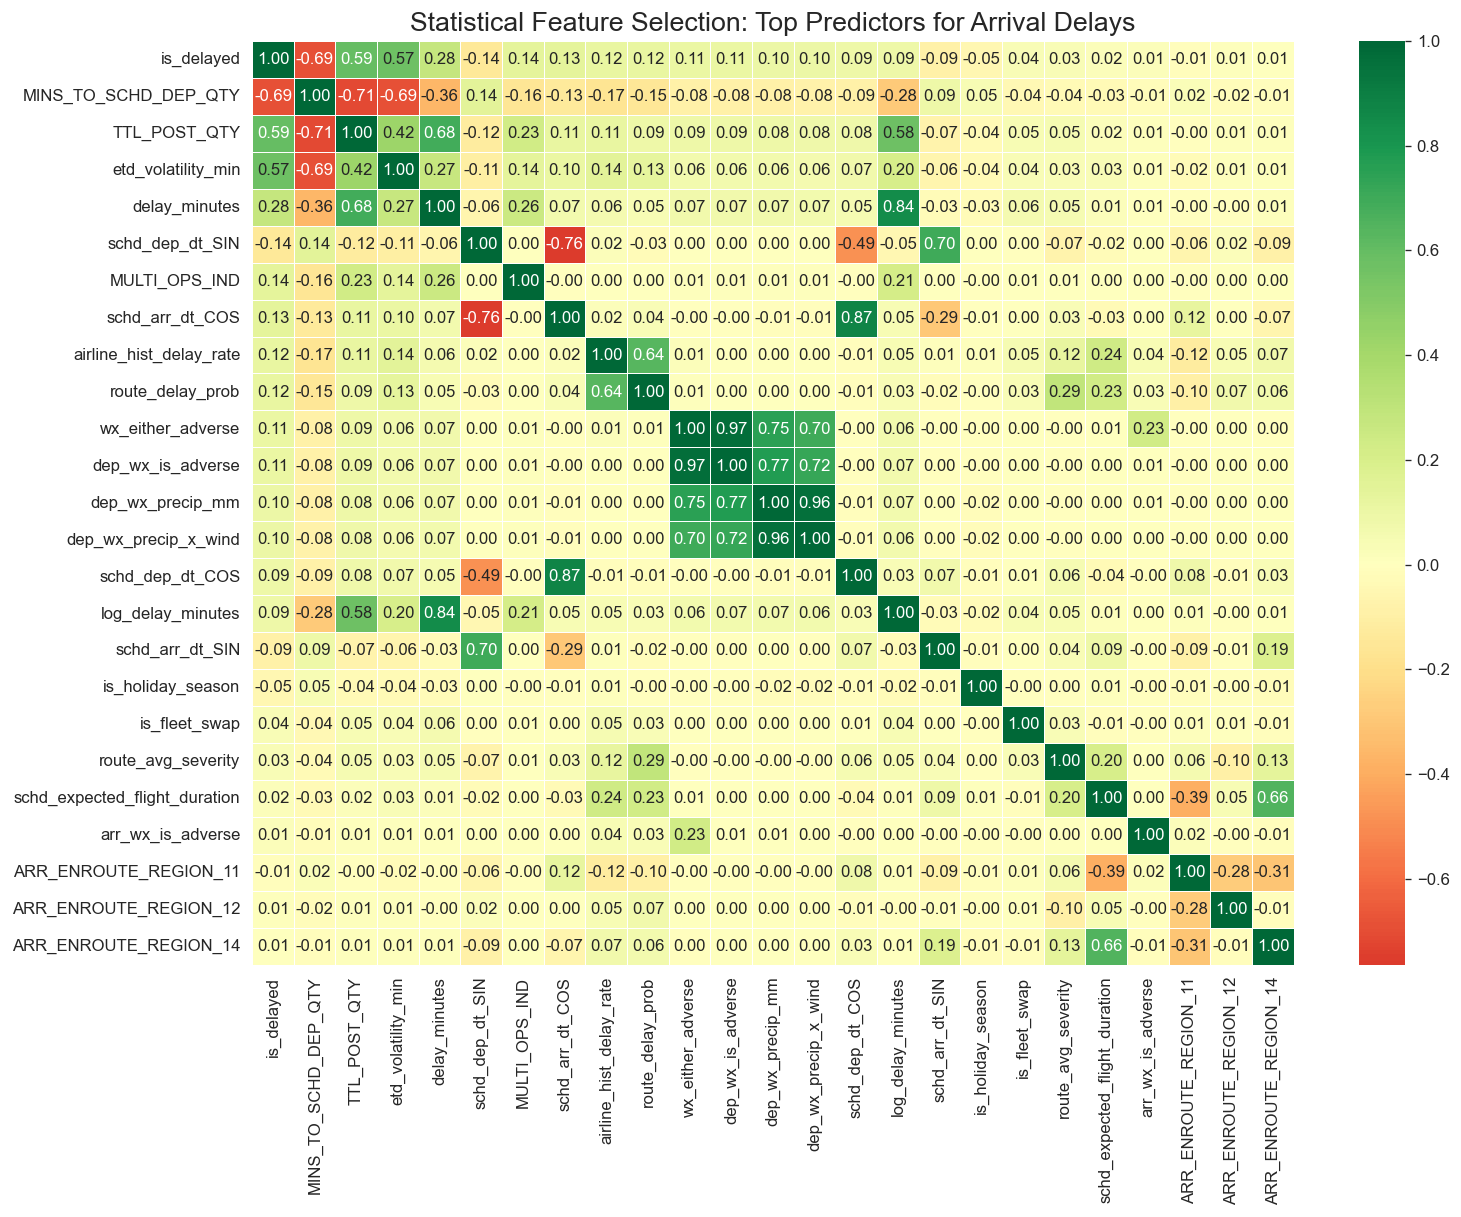

is_delayed
0    0.704199
1    0.295801
Name: proportion, dtype: float64
Delay rate: 57.5%
count    1.266641e+06
mean     4.331166e+01
std      4.068710e+01
min      1.000000e+01
25%      3.600000e+01
50%      3.600000e+01
75%      3.600000e+01
max      4.840000e+02
Name: delay_minutes, dtype: float64


In [12]:
targets_to_keep = ["is_delayed", "delay_minutes", "log_delay_minutes"]

constant_cols  = [c for c in df_transformed.columns if df_transformed[c].nunique() <= 1 and c not in targets_to_keep]
high_null_cols = [c for c in df_transformed.columns if df_transformed[c].isnull().sum() > 0.5 * len(df_transformed) and c not in targets_to_keep]
initial_drop   = list(set(constant_cols + high_null_cols))
print(f"Removing {len(initial_drop)} columns: {initial_drop}")

df_clean = df_transformed.drop(columns=initial_drop, errors="ignore")
if "ARR_ENROUTE_REGION_-1" in df_clean.columns:
    df_clean.drop(columns=["ARR_ENROUTE_REGION_-1"], inplace=True)

numeric_df = df_transformed.select_dtypes(include=[np.number, "bool"]).fillna(df_clean.select_dtypes(include=[np.number, "bool"]).median())

modeling_features = [
    'MINS_TO_SCHD_DEP_QTY', 'TTL_POST_QTY','MULTI_OPS_IND',
    'schd_expected_flight_duration', 'is_fleet_swap',      # Flight characteristics
    'etd_volatility_min', 'airline_hist_delay_rate',       # System dynamics 
    'route_delay_prob', 'route_avg_severity',
    'schd_dep_dt_SIN', 'schd_dep_dt_COS',                  # Time (cyclic encoding)
    'schd_arr_dt_SIN', 'schd_arr_dt_COS', 'is_holiday_season',
    'dep_wx_precip_mm', 'dep_wx_is_adverse', 'dep_wx_precip_x_wind',     # precipitation at departure , 'dep_wx_is_adverse'
    'arr_wx_is_adverse', 'wx_either_adverse',
    'ARR_ENROUTE_REGION_11', 'ARR_ENROUTE_REGION_12',                     # Region (geography proxy)
    'ARR_ENROUTE_REGION_13', 'ARR_ENROUTE_REGION_14', 'ARR_ENROUTE_REGION_15'
]
target_cols = ['is_delayed', 'delay_minutes', 'log_delay_minutes']

full_subset_df = numeric_df[modeling_features + target_cols].copy()
X_final = full_subset_df.copy()
print("\n--- FINAL MODEL FEATURES ---")
print(X_final.columns.tolist())
print(f"Final Feature Count: {X_final.shape}")

upper = X_final.corr().abs()
upper = upper.where(np.triu(np.ones(upper.shape), k=1).astype(bool))
auto_drop_redundant = [c for c in upper.columns if any(upper[c] > 0.90) and c not in targets_to_keep]
print(f"Auto-identified {len(auto_drop_redundant)} redundant columns: {auto_drop_redundant}")

top_corr_features = X_final.corr()["is_delayed"].abs().sort_values(ascending=False).head(25).index
plt.figure(figsize=(14, 10))
sns.heatmap(X_final[top_corr_features].corr(), annot=True, cmap="RdYlGn", center=0, fmt=".2f", linewidths=0.5)
plt.title("Statistical Feature Selection: Top Predictors for Arrival Delays", fontsize=16)
plt.show()

print(X_final['is_delayed'].value_counts(normalize=True))
print(f'Delay rate: {df_merged_final["is_delayed"].mean():.1%}')
print(X_final['delay_minutes'].describe())

# Hold-Out Validation Set (10% of Data)

We carve out 10% of rows **before** train/test splitting so the model never sees these rows during training or hyperparameter tuning. This gives us a truly unseen final evaluation.

In [13]:
# SPLIT INTO (TRAIN+TEST) AND (VALIDATION)
y_all = X_final["is_delayed"]
X_remaining, X_sample_validation = train_test_split(
    X_final, test_size=0.10, random_state=42, stratify=y_all
)

print(f"X_remaining (train+test) Rows : {X_remaining.shape}")
print(f"X_sample_validation Rows      : {X_sample_validation.shape}")
print(f"Delay rate in remaining    : {X_remaining['is_delayed'].mean():.2%}")
print(f"Delay rate in validation   : {X_sample_validation['is_delayed'].mean():.2%}")

X_remaining (train+test) Rows : (1139976, 27)
X_sample_validation Rows      : (126665, 27)
Delay rate in remaining    : 29.58%
Delay rate in validation   : 29.58%


# Extract Target Variables from Remaining & Validation Sets

In [14]:
# Validation
y_val_class = X_sample_validation["is_delayed"].copy()
y_val_reg_log = X_sample_validation["log_delay_minutes"].copy()
y_val_reg_min = X_sample_validation["delay_minutes"].copy()
X_val_feats = X_sample_validation[modeling_features].copy()

# Remaining (for training/testing)
y_remaining_class = X_remaining["is_delayed"].copy()
y_remaining_reg_log = X_remaining["log_delay_minutes"].copy()
X_remaining_feats = X_remaining[modeling_features].copy()

print(f"Validation Features Shape : {X_val_feats.shape}")
print(f"Remaining Features Shape  : {X_remaining_feats.shape}")


Validation Features Shape : (126665, 24)
Remaining Features Shape  : (1139976, 24)


# Train / Test Split for Classification (80 / 20)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_remaining_feats, y_remaining_class, test_size=0.20, random_state=42, stratify=y_remaining_class
)

print(f'Training Rows               : {X_train.shape[0]:,}')
print(f'Testing Rows                : {X_test.shape[0]:,}')
print(f'Delay Ratio in Training     : {y_train.mean():.2%}')
print(f'Delay Ratio in Test         : {y_test.mean():.2%}')
print("\nX_train Features :", X_train.columns.tolist())
X_train.shape

Training Rows               : 911,980
Testing Rows                : 227,996
Delay Ratio in Training     : 29.58%
Delay Ratio in Test         : 29.58%

X_train Features : ['MINS_TO_SCHD_DEP_QTY', 'TTL_POST_QTY', 'MULTI_OPS_IND', 'schd_expected_flight_duration', 'is_fleet_swap', 'etd_volatility_min', 'airline_hist_delay_rate', 'route_delay_prob', 'route_avg_severity', 'schd_dep_dt_SIN', 'schd_dep_dt_COS', 'schd_arr_dt_SIN', 'schd_arr_dt_COS', 'is_holiday_season', 'dep_wx_precip_mm', 'dep_wx_is_adverse', 'dep_wx_precip_x_wind', 'arr_wx_is_adverse', 'wx_either_adverse', 'ARR_ENROUTE_REGION_11', 'ARR_ENROUTE_REGION_12', 'ARR_ENROUTE_REGION_13', 'ARR_ENROUTE_REGION_14', 'ARR_ENROUTE_REGION_15']


(911980, 24)

# Classification Models – Definition

In [16]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=12, class_weight="balanced",
        random_state=42, n_jobs=-1, max_samples=0.1
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
        tree_method="hist", eval_metric="logloss", random_state=42, n_jobs=-1
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
        random_state=42, n_jobs=-1, verbose=-1
    ),
}

# Classification Models – Training & Evaluation on Test Set

In [17]:
results = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)

    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "Accuracy":           report["accuracy"],
        "Recall (Delayed)":   report["1"]["recall"],
        "F1-Score (Delayed)": report["1"]["f1-score"],
        "AUC-ROC":            roc_auc_score(y_test, y_proba),
    }

results_df = pd.DataFrame(results).T.sort_values(by="AUC-ROC", ascending=False)
print("\n--- CLASSIFICATION: TEST SET RESULTS ---")
print(results_df.round(4))

Training Logistic Regression...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...
Training XGBoost...
Training LightGBM...

--- CLASSIFICATION: TEST SET RESULTS ---
                     Accuracy  Recall (Delayed)  F1-Score (Delayed)  AUC-ROC
XGBoost                0.8821            0.8175              0.8040   0.9214
LightGBM               0.8815            0.8164              0.8029   0.9204
Random Forest          0.8679            0.8347              0.7890   0.9171
Logistic Regression    0.8689            0.8324              0.7897   0.9081


# Classification – ROC Curve Comparison

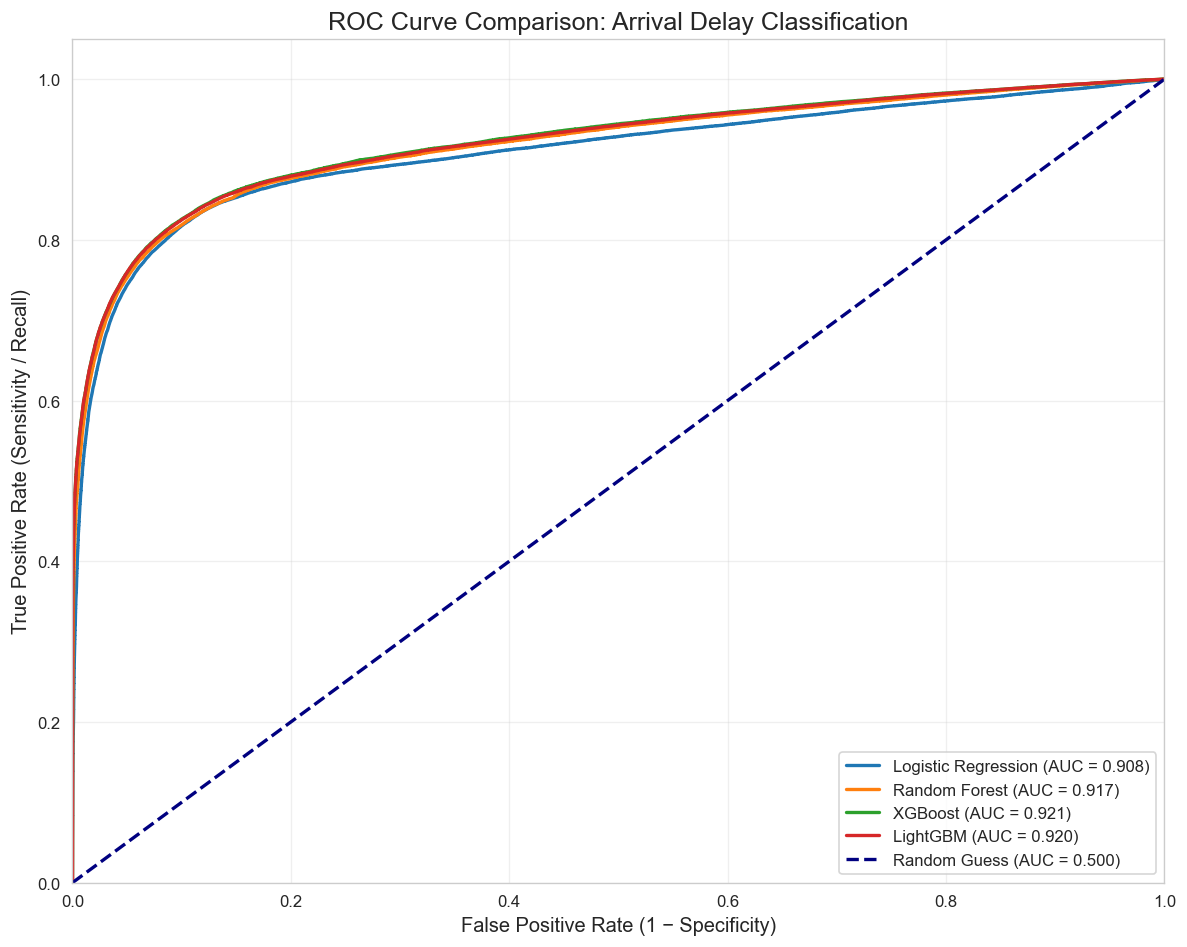

In [18]:
plt.figure(figsize=(10, 8))

for name, clf in classifiers.items():
    y_proba = clf.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1],[0,1], color="navy", lw=2, linestyle="--", label="Random Guess (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 − Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
plt.title("ROC Curve Comparison: Arrival Delay Classification", fontsize=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Classification – Evaluation on Held-Out Validation Set

The model has **never** seen these rows during training or test-set evaluation.

CLASSIFICATION VALIDATION RESULTS (Held-Out 10%)
Best Model          : XGBoost
Validation AUC-ROC  : 0.9222
Validation Accuracy : 0.8835

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.92      0.91      0.92     89197
           1       0.79      0.82      0.81     37468

    accuracy                           0.88    126665
   macro avg       0.86      0.87      0.86    126665
weighted avg       0.88      0.88      0.88    126665



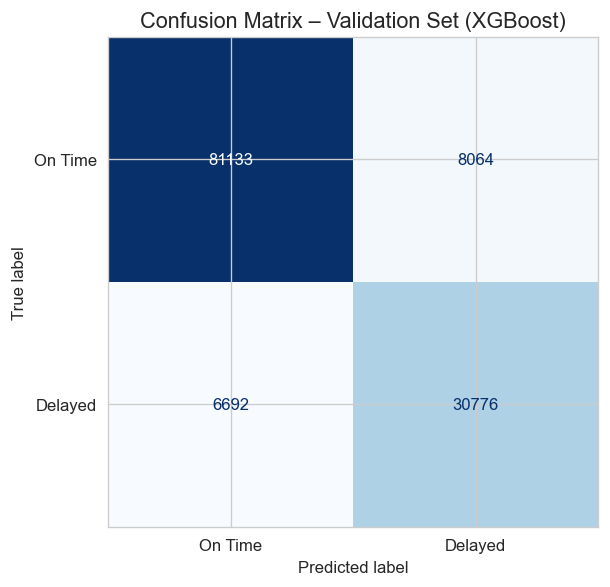

In [19]:
print("=" * 60)
print("CLASSIFICATION VALIDATION RESULTS (Held-Out 10%)")
print("=" * 60)

# 1. Identify the best model from your previous results
best_cls_name = results_df.index[0]
best_clf      = classifiers[best_cls_name]

# 3. Generate Predictions
y_val_pred  = best_clf.predict(X_val_feats)
y_val_proba = best_clf.predict_proba(X_val_feats)[:, 1]
val_auc     = roc_auc_score(y_val_class, y_val_proba)

# 4. Print Summary Metrics
print(f"Best Model          : {best_cls_name}")
print(f"Validation AUC-ROC  : {val_auc:.4f}")
print(f"Validation Accuracy : {(y_val_pred == y_val_class).mean():.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val_class, y_val_pred))

# 5. Plot Confusion Matrix
cm   = confusion_matrix(y_val_class, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On Time", "Delayed"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix – Validation Set ({best_cls_name})", fontsize=13)
plt.tight_layout()
plt.show() #

# Regression Models – Data Preparation

We predict **how many minutes** a flight will be delayed, using only rows where `is_delayed == 1`.
Training on on-time rows (where `delay_minutes` is NaN) would corrupt the regression target.

In [20]:
delayed_mask_rem = (X_remaining["is_delayed"] == 1)

X_reg_pool = X_remaining_feats[delayed_mask_rem].copy()
y_reg_pool = y_remaining_reg_log[delayed_mask_rem].copy() # log target

print(f"Total delayed flights for training/testing: {X_reg_pool.shape[0]:,}")

# --- REGRESSION VALIDATION: DELAYED FLIGHTS ONLY ---
# We use the 10% held-out validation set for the final test
delayed_mask_val = (y_val_class == 1)

X_reg_val_feats = X_val_feats[delayed_mask_val].copy()
y_reg_val_log   = y_val_reg_log[delayed_mask_val].copy()
y_reg_val_min   = y_val_reg_min[delayed_mask_val].copy() # raw minutes for scoring

print(f"Total delayed flights for final validation: {X_reg_val_feats.shape[0]:,}")

Total delayed flights for training/testing: 337,206
Total delayed flights for final validation: 37,468


# Regression – Train / Validation / Test Split

We reuse the same 10% validation hold-out (delayed flights only) and split the remaining 90% as 80/20 train/test.

In [21]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_pool, y_reg_pool, test_size=0.20, random_state=42
)

print(f"Regression Training Rows: {X_train_reg.shape[0]:,}")
print(f"Regression Test Rows    : {X_test_reg.shape[0]:,}")

Regression Training Rows: 269,764
Regression Test Rows    : 67,442


# Regression Models – Training & Evaluation on Test Set

Four models: Ridge (linear baseline), Random Forest, XGBoost, LightGBM.
All predict `log1p(delay_minutes)`; we invert with `expm1()` for final minute predictions.

In [22]:
regressors = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, tree_method="hist", random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1)
}

reg_results = {}

for name, reg in regressors.items():
    print(f"Training {name}...")
    reg.fit(X_train_reg, y_train_reg)

    # Predict on Test Set
    y_pred_log = reg.predict(X_test_reg)
    y_pred_min = np.expm1(y_pred_log) # Convert back from log to minutes
    y_test_min = np.expm1(y_test_reg)

    reg_results[name] = {
        "MAE (min)": mean_absolute_error(y_test_min, y_pred_min),
        "RMSE (min)": np.sqrt(mean_squared_error(y_test_min, y_pred_min)),
        "R2": r2_score(y_test_min, y_pred_min)
    }

reg_results_df = pd.DataFrame(reg_results).T.sort_values(by="MAE (min)")
print("\n--- REGRESSION: TEST SET RESULTS ---")
print(reg_results_df.round(3))

# Pick the best regressor
best_reg_name = reg_results_df.index[0]
best_reg = regressors[best_reg_name]

Training Ridge...
Training Random Forest...
Training XGBoost...
Training LightGBM...

--- REGRESSION: TEST SET RESULTS ---
               MAE (min)  RMSE (min)      R2
XGBoost           18.845      37.373   0.730
LightGBM          18.869      37.435   0.729
Random Forest     19.058      37.478   0.729
Ridge             40.945     648.582 -80.279


# Regression – Actual vs Predicted Plot (Test Set)

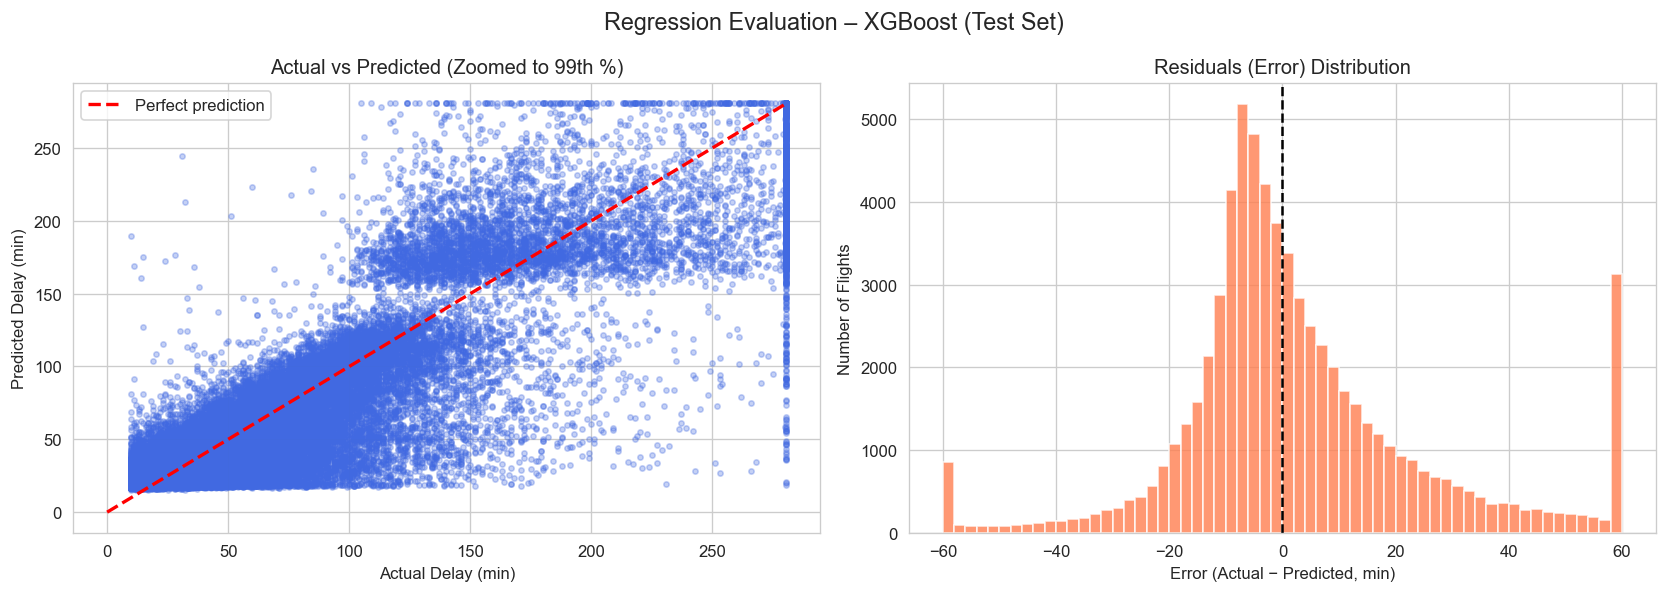

--- XGBoost Performance ---

Test Set  | MAE : 18.84 min
Test Set  | RMSE: 37.37 min
Test Set  | R2  : 0.7301


In [23]:
# 1. Select the best model based on the lowest MAE
best_reg_name = reg_results_df.index[0]
best_reg      = regressors[best_reg_name]

# 2. Generate predictions on the Test Set
y_pred_log = best_reg.predict(X_test_reg)

# 3. Transform back to original units (minutes) We use expm1 because we likely used log1p to train
y_pred_min = np.expm1(y_pred_log)
y_test_min = np.expm1(y_test_reg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Regression Evaluation – {best_reg_name} (Test Set)", fontsize=14)

ax = axes[0]
# Clipping at the 99th percentile prevents extreme outliers from squishing the plot
max_val = min(np.percentile(y_test_min, 99), np.percentile(y_pred_min, 99))

ax.scatter(y_test_min.clip(0, max_val), y_pred_min.clip(0, max_val), alpha=0.3, s=10, color="royalblue")
ax.plot([0, max_val], [0, max_val], color="red", lw=2, linestyle="--", label="Perfect prediction")

ax.set_xlabel("Actual Delay (min)")
ax.set_ylabel("Predicted Delay (min)")
ax.set_title("Actual vs Predicted (Zoomed to 99th %)")
ax.legend()

# Subplot 2: Residuals Distribution
ax = axes[1]
residuals = y_test_min - y_pred_min
# We focus the histogram on +/- 60 minutes to see the "typical" error
ax.hist(residuals.clip(-60, 60), bins=60, color="coral", edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", lw=1.5, linestyle="--")

ax.set_xlabel("Error (Actual − Predicted, min)")
ax.set_ylabel("Number of Flights")
ax.set_title("Residuals (Error) Distribution")

plt.tight_layout()
plt.show()

# 5. Print Final Test Metrics
print(f"--- {best_reg_name} Performance ---")
print(f'\nTest Set  | MAE : {reg_results_df.loc[best_reg_name, "MAE (min)"]:.2f} min')
print(f'Test Set  | RMSE: {reg_results_df.loc[best_reg_name, "RMSE (min)"]:.2f} min')
print(f'Test Set  | R2  : {reg_results_df.loc[best_reg_name, "R2"]:.4f}')

# Regression – XGBoost Feature Importance

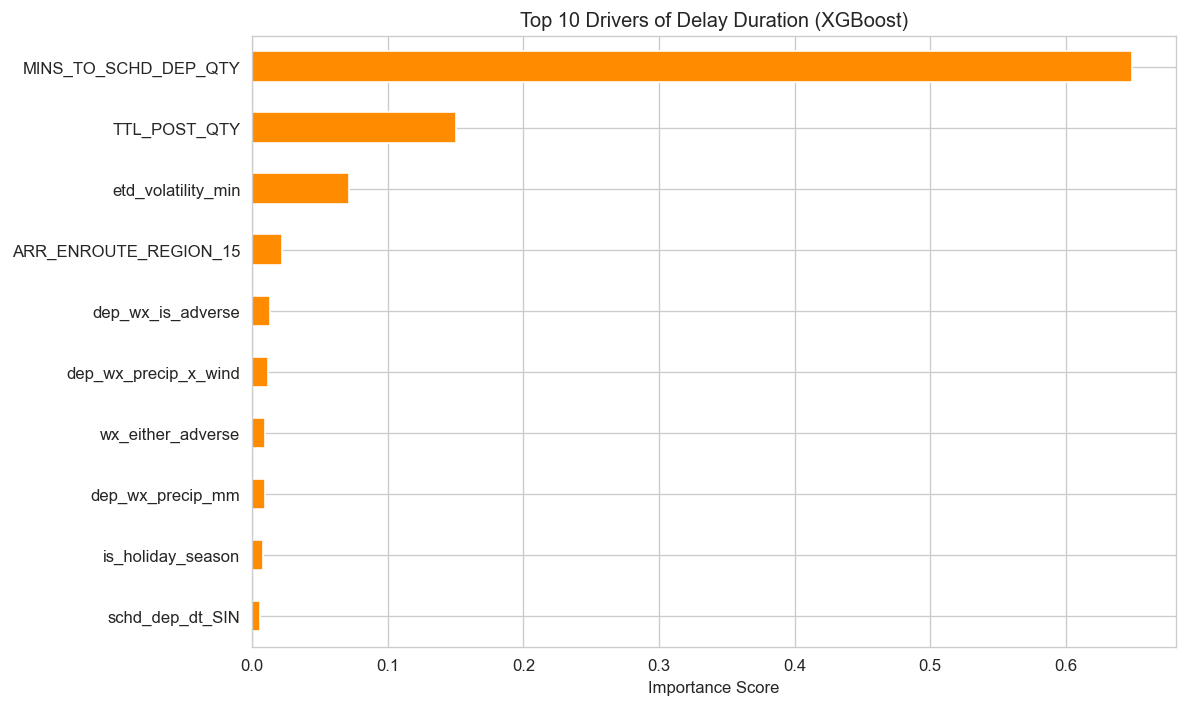

In [24]:
# Using XGBoost for importance (common choice)
xgb_reg = regressors["XGBoost"]
reg_feat_imp = pd.Series(xgb_reg.feature_importances_, index=X_train_reg.columns)

plt.figure(figsize=(10, 6))
reg_feat_imp.nlargest(10).sort_values(ascending=True).plot(kind="barh", color="darkorange")
plt.title(f"Top 10 Drivers of Delay Duration ({best_reg_name})")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Regression – Evaluation on Held-Out Validation Set

Final check: model predicts delay minutes on rows it has **never** seen before.

In [25]:
print("=" * 60)
print("REGRESSION VALIDATION RESULTS (Held-Out 10% – Delayed Only)")
print("=" * 60)

# 1. Prediction (Ensure the name matches your validation feature matrix) We use the features we filtered earlier for delayed-only flights
y_val_pred_log = best_reg.predict(X_reg_val_feats)

# 2. Transform back to original scale (Minutes)
y_val_pred_min   = np.expm1(y_val_pred_log)
# Use the raw minutes target we saved earlier for the most accurate comparison
y_val_actual_min = y_reg_val_min 

# 3. Calculate Final Validation Metrics
mae_val  = mean_absolute_error(y_val_actual_min, y_val_pred_min)
rmse_val = np.sqrt(mean_squared_error(y_val_actual_min, y_val_pred_min))
r2_val   = r2_score(y_val_actual_min, y_val_pred_min)

print(f"Best Regressor  : {best_reg_name}")
print(f"Validation MAE  : {mae_val:.2f} min")
print(f"Validation RMSE : {rmse_val:.2f} min")
print(f"Validation R2   : {r2_val:.4f}")

REGRESSION VALIDATION RESULTS (Held-Out 10% – Delayed Only)
Best Regressor  : XGBoost
Validation MAE  : 18.76 min
Validation RMSE : 37.08 min
Validation R2   : 0.7356


# Final Summary – All Model Results

In [26]:
print("\n" + "=" * 70)
print(" CLASSIFICATION SUMMARY (Test Set Results)")
print("=" * 70)
print(results_df.round(4))

print("\n" + "=" * 70)
print(" REGRESSION SUMMARY (Test Set Results — Delayed Only)")
print("=" * 70)
print(reg_results_df.round(3))

print("\n" + "=" * 70)
print(" FINAL VALIDATION SCORES (Held-Out 10% Set)")
print("=" * 70)

# Safety check: Ensure we use the variables defined in your split section
# We use the full 10% validation set for Classification AUC
val_auc = roc_auc_score(y_val_class, best_clf.predict_proba(X_val_feats)[:, 1])

print(f" Best Classifier        : {best_cls_name}")
print(f" Classification AUC-ROC : {val_auc:.4f}")
print("-" * 40)

# These three variables (mae_val, rmse_val, r2_val) were calculated 
# in the 'Regression Validation' block specifically for delayed flights.
print(f" Best Regressor         : {best_reg_name}")
print(f" Regression MAE         : {mae_val:.2f} min")
print(f" Regression RMSE        : {rmse_val:.2f} min")
print(f" Regression R2          : {r2_val:.4f}")
print("=" * 70)


 CLASSIFICATION SUMMARY (Test Set Results)
                     Accuracy  Recall (Delayed)  F1-Score (Delayed)  AUC-ROC
XGBoost                0.8821            0.8175              0.8040   0.9214
LightGBM               0.8815            0.8164              0.8029   0.9204
Random Forest          0.8679            0.8347              0.7890   0.9171
Logistic Regression    0.8689            0.8324              0.7897   0.9081

 REGRESSION SUMMARY (Test Set Results — Delayed Only)
               MAE (min)  RMSE (min)      R2
XGBoost           18.845      37.373   0.730
LightGBM          18.869      37.435   0.729
Random Forest     19.058      37.478   0.729
Ridge             40.945     648.582 -80.279

 FINAL VALIDATION SCORES (Held-Out 10% Set)
 Best Classifier        : XGBoost
 Classification AUC-ROC : 0.9222
----------------------------------------
 Best Regressor         : XGBoost
 Regression MAE         : 18.76 min
 Regression RMSE        : 37.08 min
 Regression R2          : 0.7356

# CLASSIFICATION and Regression ERROR ANALYSIS (XGBoost)

In [27]:
cm = confusion_matrix(y_val_class, y_val_pred)

# 2. Extract specific counts (Order: TN, FP, FN, TP)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print(f"CLASSIFICATION ERROR ANALYSIS ({best_cls_name})")
print("=" * 60)
print(f" True Negatives (TN)  : {tn:,}  (Correctly predicted 'On Time')")
print(f" True Positives (TP)  : {tp:,}  (Correctly predicted 'Delayed')")
print(f" False Positives (FP) : {fp:,}  (False Alarm - predicted delay but was on time)")
print(f" False Negatives (FN) : {fn:,}  (Missed Delay - predicted on time but was late)")
print("-" * 60)

# Calculate precision/recall manually for clarity
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"Precision: {precision:.2%} (When model says 'Delayed', it is right this often)")
print(f"Recall:    {recall:.2%} (Model catches this % of all actual delays)")

# residuals = Actual Minutes - Predicted Minutes
residuals_val = y_val_actual_min - y_val_pred_min

over_predicted  = (residuals_val < 0).sum()
under_predicted = (residuals_val > 0).sum()
exact_match     = (residuals_val == 0).sum()

print("\n" + "=" * 60)
print(f"REGRESSION ERROR ANALYSIS ({best_reg_name})")
print("=" * 60)
print(f" Over-Predicted  : {over_predicted:,} flights")
print(f"   (Model predicted a LONGER delay than what actually happened)")

print(f" Under-Predicted : {under_predicted:,} flights")
print(f"   (Model predicted a SHORTER delay than what actually happened)")

print("-" * 60)
print(f"Average Error (MAE): {mae_val:.2f} minutes")

CLASSIFICATION ERROR ANALYSIS (XGBoost)
 True Negatives (TN)  : 81,133  (Correctly predicted 'On Time')
 True Positives (TP)  : 30,776  (Correctly predicted 'Delayed')
 False Positives (FP) : 8,064  (False Alarm - predicted delay but was on time)
 False Negatives (FN) : 6,692  (Missed Delay - predicted on time but was late)
------------------------------------------------------------
Precision: 79.24% (When model says 'Delayed', it is right this often)
Recall:    82.14% (Model catches this % of all actual delays)

REGRESSION ERROR ANALYSIS (XGBoost)
 Over-Predicted  : 20,334 flights
   (Model predicted a LONGER delay than what actually happened)
 Under-Predicted : 17,134 flights
   (Model predicted a SHORTER delay than what actually happened)
------------------------------------------------------------
Average Error (MAE): 18.76 minutes


# Hyperparameter Tuning

In [28]:
tscv = TimeSeriesSplit(n_splits=5)

# ---- CLASSIFIER TUNING (XGBoost) ---- Baseline: AUC=0.9226, Precision=79.24%, Recall=82.17%
# Goal: push AUC above 0.925, tighten FP (8065) without hurting recall
print('Tuning XGBoost Classifier...')
cls_param_grid = {
    'n_estimators'    : [200, 300, 400, 500],
    'max_depth'       : [3, 4, 5, 6],           # shallower than before (was up to 8) → fewer FP
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [3, 5, 7, 10],          # raised floor (was 1) → reduces noisy FP splits
    'gamma'           : [0.1, 0.2, 0.5, 1.0],  # raised floor (was 0) → penalizes weak splits
    'reg_alpha'       : [0.01, 0.1, 0.5, 1.0],
    'reg_lambda'      : [1.5, 2, 3, 5],
}
xgb_cls_base = xgb.XGBClassifier(scale_pos_weight=scale_pos,eval_metric='logloss',random_state=42,n_jobs=-1)

cls_search = RandomizedSearchCV(xgb_cls_base, cls_param_grid,n_iter=50,
    scoring='average_precision',  cv=tscv, random_state=42, n_jobs=-1, verbose=1)

cls_search.fit(X_train, y_train)
print(f'  Best CV AUC-PR (classifier): {cls_search.best_score_:.4f}')
print(f'  Best params: {cls_search.best_params_}')
tuned_cls = cls_search.best_estimator_

# ---- REGRESSOR TUNING (XGBoost ) ---- Baseline: MAE=18.75, RMSE=37.18, R2=0.7342
# LightGBM was 18.849 MAE vs XGBoost 18.823 — negligible, use XGBoost for consistency
# Goal: reduce MAE below 18 min, fix over-prediction bias (20307 over vs 17161 under)
print('\nTuning XGBoost Regressor...')
reg_param_grid = {
    'n_estimators'    : [300, 400, 500, 600],
    'max_depth'       : [4, 5, 6, 7],           # removed deep trees (was up to 12) → less over-prediction
    'learning_rate'   : [0.01, 0.03, 0.05],     # slower learning → better MAE
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [5, 10, 20, 30],        # raised significantly → less sensitive to outlier delays
    'gamma'           : [0.1, 0.2, 0.5],
    'reg_alpha'       : [0.1, 0.5, 1.0],        # raised from 0 → L1 pulls predictions toward median
    'reg_lambda'      : [1.0, 2.0, 3.0],
}
xgb_reg_base = xgb.XGBRegressor(objective='reg:absoluteerror', random_state=42,n_jobs=-1)  # directly optimizes MAE instead of default MSE    

reg_search = RandomizedSearchCV(xgb_reg_base, reg_param_grid,n_iter=50,
    scoring='neg_mean_absolute_error',cv=tscv, random_state=42, n_jobs=-1, verbose=1)

reg_search.fit(X_train_reg, y_train_reg)
print(f'  Best CV MAE (regressor): {-reg_search.best_score_:.4f}')
print(f'  Best params: {reg_search.best_params_}')
tuned_reg = reg_search.best_estimator_

Tuning XGBoost Classifier...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  Best CV AUC-PR (classifier): 0.8958
  Best params: {'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 1.0, 'colsample_bytree': 0.8}

Tuning XGBoost Regressor...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  Best CV MAE (regressor): 0.3446
  Best params: {'subsample': 0.8, 'reg_lambda': 3.0, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 30, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.8}


# Tuned Model Results


Finalizing Tuned XGBoost Classifier...
Optimal Classification Threshold: 0.62 (Best F1=0.8134)
Finalizing Tuned XGBoost Regressor...
--- REGRESSION FINAL REPORT ---
MAE: 18.60 min
RMSE: 38.53 min
R2: 0.7132

          FLIGHT DELAY PREDICTION: FINAL RESULTS

--- TASK 1: Classification (Is the flight delayed?) ---
              precision    recall  f1-score   support

     On Time       0.91      0.94      0.93    160555
     Delayed       0.85      0.78      0.81     67441

    accuracy                           0.89    227996
   macro avg       0.88      0.86      0.87    227996
weighted avg       0.89      0.89      0.89    227996

FINAL TEST AUC-ROC : 0.9254

Generating SHAP explanations...


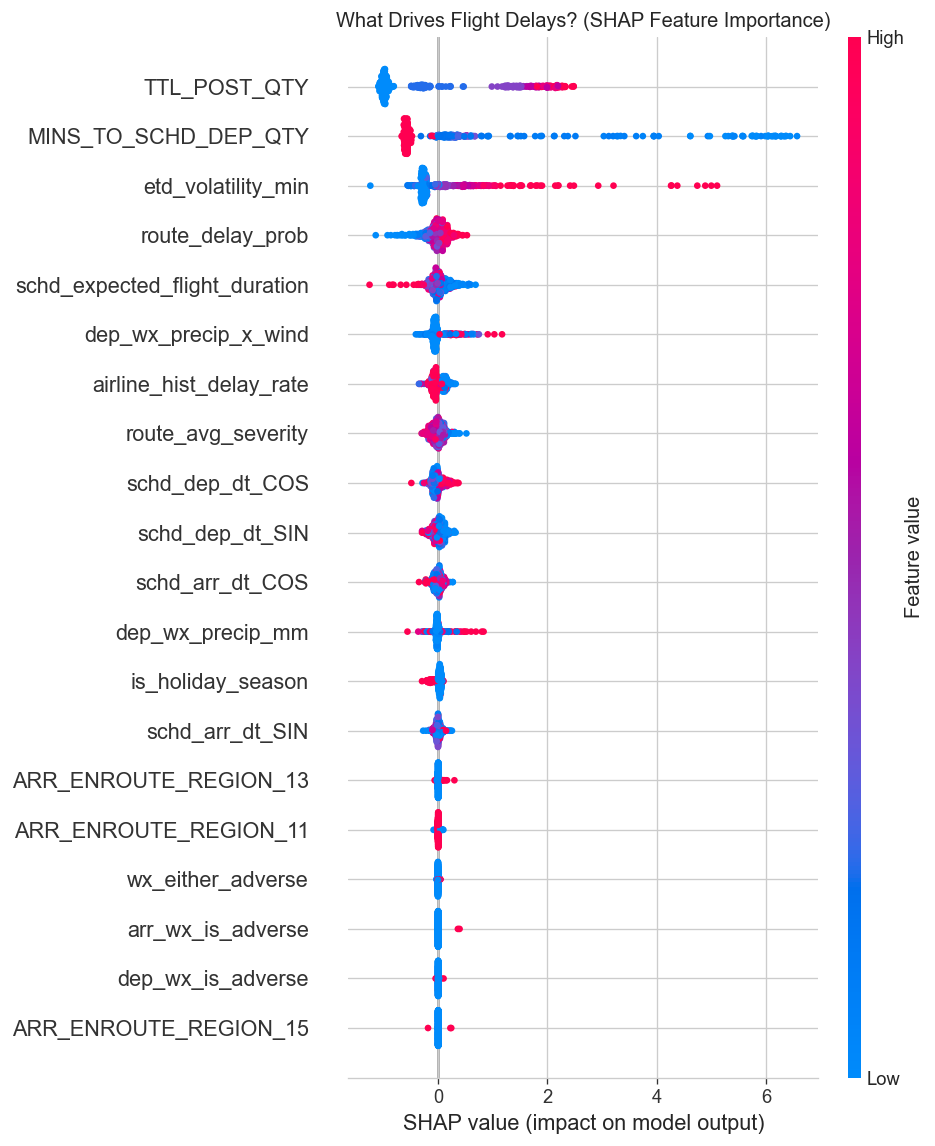

In [29]:
# ---- FINALIZE CLASSIFIER ----
print("\nFinalizing Tuned XGBoost Classifier...")
tuned_cls.fit(X_train, y_train)
final_proba = tuned_cls.predict_proba(X_test)[:, 1]

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.3, 0.8, 0.02):
    f = f1_score(y_test, (final_proba >= t).astype(int), zero_division=0)
    if f > best_f1: best_f1, best_thresh = f, t
print(f'Optimal Classification Threshold: {best_thresh:.2f} (Best F1={best_f1:.4f})')
final_pred_cls = (final_proba >= best_thresh).astype(int)

# ---- FINALIZE REGRESSOR ----
print("Finalizing Tuned XGBoost Regressor...")
tuned_reg.fit(X_train_reg, y_train_reg)
final_pred_reg_min = np.clip(np.expm1(tuned_reg.predict(X_test_reg)), 15, 720)
y_test_reg_min = full_subset_df.loc[X_test_reg.index, 'delay_minutes']
mae  = mean_absolute_error(y_test_reg_min, final_pred_reg_min)
rmse = np.sqrt(mean_squared_error(y_test_reg_min, final_pred_reg_min))
r2   = r2_score(y_test_reg_min, final_pred_reg_min)
print(f"--- REGRESSION FINAL REPORT ---\nMAE: {mae:.2f} min\nRMSE: {rmse:.2f} min\nR2: {r2:.4f}")

print('\n' + '='*60 + '\n          FLIGHT DELAY PREDICTION: FINAL RESULTS\n' + '='*60)
print('\n--- TASK 1: Classification (Is the flight delayed?) ---')
print(classification_report(y_test, final_pred_cls, target_names=['On Time', 'Delayed']))
print(f'FINAL TEST AUC-ROC : {roc_auc_score(y_test, final_proba):.4f}')

# ---- SHAP EXPLANATIONS ----
print('\nGenerating SHAP explanations...')
shap_sample = X_test.iloc[:500]
shap_values = shap.TreeExplainer(tuned_cls).shap_values(shap_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, shap_sample, feature_names=X_test.columns, show=False)
plt.title('What Drives Flight Delays? (SHAP Feature Importance)')
plt.show()

# EDA

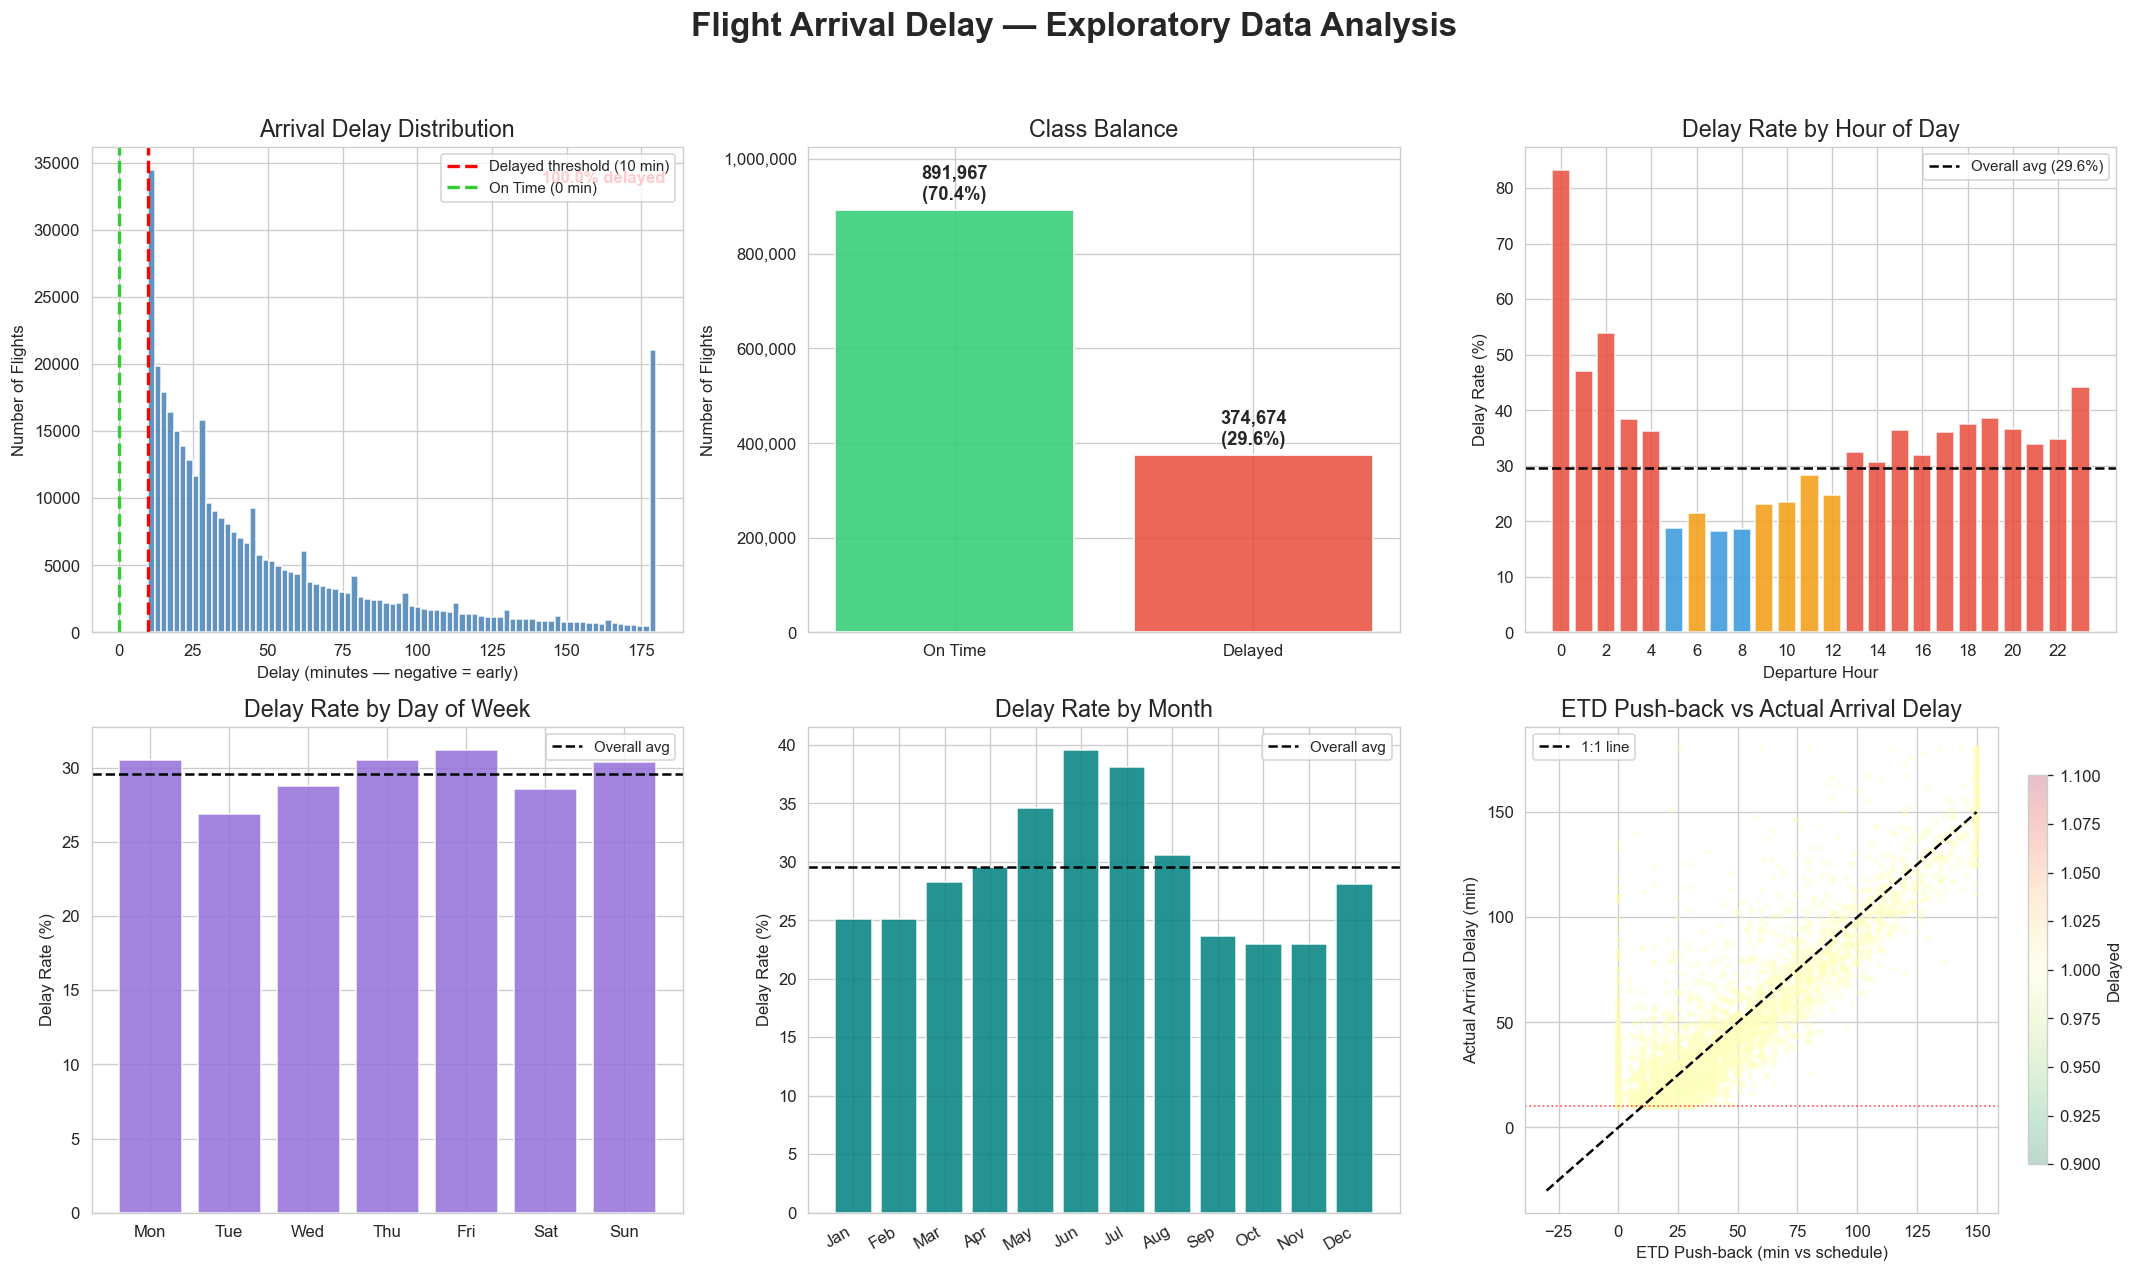

In [30]:
fe = df_transformed.copy()
DELAY_THRESHOLD_MIN = 10

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Flight Arrival Delay — Exploratory Data Analysis", fontsize=20, fontweight="bold", y=0.98)

def _blank(ax, msg):
    ax.text(0.5, 0.5, f"Column not found:\n{msg}", ha='center', va='center', transform=ax.transAxes,
            fontsize=11, color='gray', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_xticks([]); ax.set_yticks([])

# ── Plot 1: Arrival Delay Distribution ──────────────────────────────────────
ax = axes[0, 0]
delay_col = 'delay_minutes' if 'delay_minutes' in fe.columns else None
if delay_col:
    raw_col = 'LEG_ARVL_VARNCE_MIN_QTY' if 'LEG_ARVL_VARNCE_MIN_QTY' in fe.columns else delay_col
    ax.hist(fe[raw_col].clip(-60, 180).dropna(), bins=80, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(DELAY_THRESHOLD_MIN, color="red", linestyle="--", lw=2, label=f"Delayed threshold ({DELAY_THRESHOLD_MIN} min)")
    ax.axvline(0, color="limegreen", linestyle="--", lw=2, label="On Time (0 min)")
    ax.set_title("Arrival Delay Distribution", fontsize=14)
    ax.set_xlabel("Delay (minutes — negative = early)"); ax.set_ylabel("Number of Flights")
    ax.legend(fontsize=9)
    ax.text(0.97, 0.95, f"{(fe[raw_col].dropna() >= DELAY_THRESHOLD_MIN).mean():.1%} delayed",
            ha='right', va='top', transform=ax.transAxes, fontsize=10, color='red', fontweight='bold')
else:
    _blank(ax, "delay_minutes / LEG_ARVL_VARNCE_MIN_QTY")

# ── Plot 2: Class Balance ────────────────────────────────────────────────────
ax = axes[0, 1]
if 'is_delayed' in fe.columns:
    counts = fe['is_delayed'].value_counts().sort_index()
    bars = ax.bar(["On Time", "Delayed"], counts.values, color=["#2ecc71", "#e74c3c"], alpha=0.85, edgecolor='white', linewidth=1.2)
    total = len(fe)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + total*0.01, f"{v:,}\n({v/total:.1%})", ha="center", va="bottom", fontweight='bold', fontsize=11)
    ax.set_title("Class Balance", fontsize=14); ax.set_ylabel("Number of Flights")
    ax.set_ylim(0, counts.max()*1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
else:
    _blank(ax, "is_delayed")

# ── Plot 3: Delay Rate by Hour ───────────────────────────────────────────────
ax = axes[0, 2]
if 'dep_hour' in fe.columns and 'is_delayed' in fe.columns:
    hour_delay = fe.groupby('dep_hour')['is_delayed'].mean()
    colors = ['#e74c3c' if v >= 0.30 else '#f39c12' if v >= 0.20 else '#3498db' for v in hour_delay.values]
    ax.bar(hour_delay.index, hour_delay.values*100, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title("Delay Rate by Hour of Day", fontsize=14)
    ax.set_xlabel("Departure Hour"); ax.set_ylabel("Delay Rate (%)"); ax.set_xticks(range(0, 24, 2))
    ax.axhline(fe['is_delayed'].mean()*100, color='black', linestyle='--', lw=1.5, label=f"Overall avg ({fe['is_delayed'].mean():.1%})")
    ax.legend(fontsize=9)
else:
    _blank(ax, "dep_hour")

# ── Plot 4: Delay Rate by Day of Week ───────────────────────────────────────
ax = axes[1, 0]
if 'dep_dayofweek' in fe.columns and 'is_delayed' in fe.columns:
    days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    dow_delay = fe.groupby('dep_dayofweek')['is_delayed'].mean()
    valid = [(days[int(i)], v) for i, v in zip(dow_delay.index, dow_delay.values) if int(i) < 7]
    labels_f, values_f = zip(*valid) if valid else ([], [])
    ax.bar(labels_f, [v*100 for v in values_f], color="mediumpurple", alpha=0.85, edgecolor='white')
    ax.axhline(fe['is_delayed'].mean()*100, color='black', linestyle='--', lw=1.5, label='Overall avg')
    ax.set_title("Delay Rate by Day of Week", fontsize=14); ax.set_ylabel("Delay Rate (%)")
    ax.legend(fontsize=9)
else:
    _blank(ax, "dep_dayofweek")

# ── Plot 5: Delay Rate by Month ──────────────────────────────────────────────
ax = axes[1, 1]
if 'dep_month' in fe.columns and 'is_delayed' in fe.columns:
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    mon_delay = fe.groupby('dep_month')['is_delayed'].mean()
    ax.bar([month_names[max(0, min(m-1, 11))] for m in mon_delay.index.astype(int)], mon_delay.values*100, color="teal", alpha=0.85, edgecolor='white')
    ax.axhline(fe['is_delayed'].mean()*100, color='black', linestyle='--', lw=1.5, label='Overall avg')
    ax.set_title("Delay Rate by Month", fontsize=14); ax.set_ylabel("Delay Rate (%)")
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right'); ax.legend(fontsize=9)
else:
    _blank(ax, "dep_month")

# ── Plot 6: ETD Push-back vs Arrival Delay (Ripple Effect) ──────────────────
ax = axes[1, 2]
push_col = 'etd_push_back_min' if 'etd_push_back_min' in fe.columns else None
arr_col = 'LEG_ARVL_VARNCE_MIN_QTY' if 'LEG_ARVL_VARNCE_MIN_QTY' in fe.columns else 'delay_minutes'
if push_col and arr_col in fe.columns:
    sample = fe[[push_col, arr_col, 'is_delayed']].dropna().sample(min(5000, len(fe.dropna(subset=[push_col, arr_col]))), random_state=42)
    sc = ax.scatter(sample[push_col].clip(-30, 150), sample[arr_col].clip(-30, 180), c=sample['is_delayed'], cmap='RdYlGn_r', alpha=0.25, s=8)
    ax.plot([-30, 150], [-30, 150], color='black', linestyle='--', lw=1.5, label="1:1 line")
    ax.axhline(DELAY_THRESHOLD_MIN, color='red', linestyle=':', lw=1, alpha=0.7)
    ax.set_title("ETD Push-back vs Actual Arrival Delay", fontsize=14)
    ax.set_xlabel("ETD Push-back (min vs schedule)"); ax.set_ylabel("Actual Arrival Delay (min)")
    ax.legend(fontsize=9); plt.colorbar(sc, ax=ax, label='Delayed', shrink=0.8)
else:
    _blank(ax, f"etd_push_back_min or {arr_col}")

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()